<a href="https://colab.research.google.com/github/nomanamir20/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import os

# Clone the repository to access the dataset
!git clone https://github.com/nomanamir20/flyrank-ml-internship.git

# Change to the project directory if necessary, or ensure paths are relative to /content/
# os.chdir('/content/flyrank-ml-internship')

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nomanamir20/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Question

## Research Question

Can a machine-learning ranking model identify keyword-article content rows that should be prioritized for human review based on observed SEO performance signals?

## Problem

Content teams may have many keyword-article pages to review, making it difficult to decide which pages should be inspected first. The goal of this project is to use observed content-performance features to produce a ranked review queue that helps humans focus their attention on higher-priority rows.

## Decision Supported

The model supports one specific decision:

> **Which keyword-article rows should a human reviewer inspect first?**

The output is therefore a prioritization score and ranked queue rather than an automatic content-change decision.

## Success Criteria

The model is evaluated primarily as a ranking system using:

- Precision@20
- Precision@50
- Precision@100
- ROC-AUC
- Average Precision

The analysis also compares the learned model with a transparent baseline on the same validation design.

## Boundary of the Question

This project does **not** attempt to predict Google's ranking algorithm, establish causal relationships, or automatically decide what content should be published, rewritten, deleted, redirected, or changed.

The model output is treated as **decision-support** based on observed and measured signals. Human review remains necessary before any content action.

In [20]:
# Section 1: Question
# Define the research question and decision-support boundary.

research_question = (
    "Can a machine-learning ranking model identify keyword-article "
    "content rows that should be prioritized for human review based "
    "on observed SEO performance signals?"
)

decision_supported = (
    "Prioritize keyword-article rows for human review."
)

success_metrics = [
    "Precision@20",
    "Precision@50",
    "Precision@100",
    "ROC-AUC",
    "Average Precision",
]

boundaries = [
    "Decision-support only",
    "No causal claims",
    "No prediction of Google's ranking algorithm",
    "No automatic publishing",
    "No automatic rewriting",
    "No automatic deletion",
    "Human review required before content action",
]

print("RESEARCH QUESTION")
print(research_question)

print("\nDECISION SUPPORTED")
print(decision_supported)

print("\nSUCCESS METRICS")
for metric in success_metrics:
    print("-", metric)

print("\nBOUNDARIES")
for boundary in boundaries:
    print("-", boundary)

RESEARCH QUESTION
Can a machine-learning ranking model identify keyword-article content rows that should be prioritized for human review based on observed SEO performance signals?

DECISION SUPPORTED
Prioritize keyword-article rows for human review.

SUCCESS METRICS
- Precision@20
- Precision@50
- Precision@100
- ROC-AUC
- Average Precision

BOUNDARIES
- Decision-support only
- No causal claims
- No prediction of Google's ranking algorithm
- No automatic publishing
- No automatic rewriting
- No automatic deletion
- Human review required before content action


## 2. Data

This study uses the anonymized FlyRank internship starter dataset, which contains 30,000 rows and 44 columns. Each row represents a pseudonymized content item with SEO and content-performance measurements.

For this analysis, the dataset was restricted to the keyword-article lane, resulting in 27,207 rows. The analysis focuses on identifying keyword-article rows that should be prioritized for human review based on their observed decline risk.

The dataset contains numeric and categorical SEO/content features. The target variable is `is_declining_label`. The variables `trend_direction` and `trend_pct` were excluded because the label is derived from the trend information, creating a direct leakage risk. The pseudonymous identifiers `client_id` and `content_id` were also excluded from the model features and used only for grouping, joining, and validation purposes.

The dataset is anonymized and contains no client names, domains, URLs, private queries, or other directly identifying information.

The analysis uses a client-grouped validation design so that validation clients do not overlap with training clients. This provides a stricter test of whether the ranking approach generalizes across clients.

### Data scope

- Starter dataset: 30,000 rows × 44 columns
- Keyword-article analysis lane: 27,207 rows
- Numeric model features: 22
- Categorical model features: 8
- Total model features: 30
- Overall keyword-article decline rate: 56.1%

### Exclusions

The following variables were excluded from model features:

- `trend_direction` — excluded because it contributes directly to the label definition.
- `trend_pct` — excluded for the same leakage concern.
- `is_declining_label` — target variable, not a feature.
- `client_id` — retained only for client-grouped validation.
- `content_id` — retained only as an identifier and not used as a predictive feature.

The analysis is therefore based on public-safe, anonymized data and is intended for directional decision-support rather than production prediction.

In [21]:
import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Locate and load the anonymized starter dataset
# ------------------------------------------------------------

possible_paths = [
    "data/raw/content_refresh_anonymized.csv",
    "../data/raw/content_refresh_anonymized.csv",
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find content_refresh_anonymized.csv. "
        "Check that the repository is mounted/cloned and the dataset path is correct."
    )

df_raw = pd.read_csv(data_path)

# Derive 'is_declining_label' from 'trend_direction'
df_raw['is_declining_label'] = (df_raw['trend_direction'] == 'down').astype(int)

print("DATASET LOADED")
print("-" * 50)
print(f"Path: {data_path}")
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")


# ------------------------------------------------------------
# 2. Basic dataset checks
# ------------------------------------------------------------

required_columns = [
    "client_id",
    "content_id",
    "content_type",
    "is_declining_label",
    "trend_direction",
    "trend_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

print("\nCOLUMN CHECK")
print("-" * 50)
print("Required columns found:", True)


# ------------------------------------------------------------
# 3. Restrict analysis to keyword-article rows
# ------------------------------------------------------------

keyword_article_values = [
    "keyword_article",
    "keyword article",
    "keyword-article"
]

content_type_normalized = (
    df_raw["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

keyword_mask = content_type_normalized.isin(keyword_article_values)

df = df_raw.loc[keyword_mask].copy()

if len(df) == 0:
    # Fallback: inspect the available content types
    print("\nAvailable content_type values:")
    print(df_raw["content_type"].value_counts(dropna=False))
    raise ValueError(
        "No keyword-article rows were found. "
        "Check the exact content_type value used in the dataset."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 50)
print(f"Keyword article lane shape: {df.shape}")


# ------------------------------------------------------------
# 4. Target distribution
# ------------------------------------------------------------

target_col = "is_declining_label"

target_distribution = (
    df[target_col]
    .value_counts(dropna=False)
    .sort_index()
)

decline_rate = df[target_col].mean()

print("\nTARGET DISTRIBUTION")
print("-" * 50)
print(target_distribution)

print(f"\nOverall keyword-article decline rate: {decline_rate:.4f}")
print(f"Overall keyword-article decline rate: {decline_rate:.2%}")


# ------------------------------------------------------------
# 5. Define excluded columns
# ------------------------------------------------------------

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id"
]

missing_excluded = [
    col for col in excluded_columns
    if col not in df.columns
]

if missing_excluded:
    raise ValueError(
        f"Expected excluded columns are missing: {missing_excluded}"
    )


# ------------------------------------------------------------
# 6. Build model feature list
# ------------------------------------------------------------

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[target_col].copy()

numeric_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("\nFEATURE SUMMARY")
print("-" * 50)
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total model features: {len(feature_columns)}")

print("\nEXCLUDED VARIABLES")
print("-" * 50)

for col in excluded_columns:
    print(f"{col} : excluded")


# ------------------------------------------------------------
# 7. Missingness summary
# ------------------------------------------------------------

missing_summary = (
    X.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

print("\nMISSINGNESS CHECK")
print("-" * 50)

if len(missing_summary) == 0:
    print("No missing values found in model features.")
else:
    print(
        missing_summary.head(10)
        .to_string()
    )


# ------------------------------------------------------------
# 8. Client information for grouped validation
# ------------------------------------------------------------

client_count = df["client_id"].nunique()
content_count = df["content_id"].nunique()

print("\nIDENTIFIER SUMMARY")
print("-" * 50)
print(f"Unique clients: {client_count}")
print(f"Unique content items: {content_count}")


# ------------------------------------------------------------
# 9. Public-safety checks
# ------------------------------------------------------------

private_columns = [
    "client_name",
    "domain",
    "url",
    "query",
    "keyword"
]

present_private_columns = [
    col for col in private_columns
    if col in df.columns
]

print("\nPUBLIC-SAFETY CHECK")
print("-" * 50)

if len(present_private_columns) == 0:
    print("No known private-name, domain, URL, query, or keyword columns detected.")
else:
    print(
        "Potential private columns detected:",
        present_private_columns
    )


# ------------------------------------------------------------
# 10. Store reusable variables for later sections
# ------------------------------------------------------------

data_summary = {
    "dataset_rows": int(df_raw.shape[0]),
    "dataset_columns": int(df_raw.shape[1]),
    "keyword_article_rows": int(df.shape[0]),
    "keyword_article_columns": int(df.shape[1]),
    "decline_rate": float(decline_rate),
    "numeric_features": int(len(numeric_features)),
    "categorical_features": int(len(categorical_features)),
    "total_features": int(len(feature_columns)),
    "unique_clients": int(client_count),
    "unique_content_items": int(content_count)
}

print("\nSECTION 2 DATA SUMMARY")
print("-" * 50)

for key, value in data_summary.items():
    print(f"{key}: {value}")

DATASET LOADED
--------------------------------------------------
Path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv
Dataset shape: (30000, 45)
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'is_declining_label']

COLUMN CHECK
--------------

## 3. Methodology

### Assumptions

This study treats the task as a binary classification and ranking problem. The objective is to prioritize keyword-article rows that warrant human review based on observed historical signals.

The model is intended as a **decision-support system**, not as an automated content-management system. Model scores do not automatically trigger publishing, rewriting, deletion, redirects, or other production changes.

The analysis is performed on rows in the selected keyword-article lane. Client identifiers are retained for grouped validation but are excluded from the model features. Content identifiers are treated as identifiers only and are also excluded from the model features.

The observed decline label is used as an evaluation outcome. It is not interpreted as evidence that any particular feature or model input causally caused the decline.

### Features

The keyword-article analysis uses the available numeric and categorical variables after removing variables that could introduce leakage or identifier-based memorization.

The excluded variables are:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

`trend_direction` and `trend_pct` are excluded because they are directly related to the construction of the target outcome. `client_id` and `content_id` are excluded because they are identifiers rather than generalizable predictive features.

The remaining variables form the model feature set and include performance, traffic, engagement, content, freshness, competition, and search-related attributes available in the anonymized dataset.

### Label Definition

The target variable is:

`is_declining_label`

The target is binary:

- `1` = declining
- `0` = not declining

The label is derived from the available trend information rather than being used as a raw model input.

The label is used only for supervised learning and evaluation. The model score is interpreted as a prioritization signal rather than as a causal explanation of why an article declined.

### Baseline

A transparent baseline ranking is used as the reference point for evaluating whether the learned model provides useful prioritization beyond a simple non-learned approach.

The baseline and learned model are evaluated using the same ranking-oriented evaluation framework so that the comparison reflects the same task.

### Validation Design

The validation strategy uses **client-grouped holdout validation**.

Clients assigned to the validation set are not present in the training set. This prevents the model from being evaluated on clients it has already seen during training and provides a more realistic test of generalization to unseen clients.

The validation design therefore prioritizes client-level separation rather than relying only on a random row-level split.

The final validated holdout contains:

- **Validation rows:** 2,789
- **Validation clients:** 5
- **Client overlap:** 0

### Leakage Checks

Several leakage controls are applied before model training.

The following variables are explicitly excluded from the model feature matrix:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

This prevents the target itself, variables used to construct the target, and row/client identifiers from becoming model inputs.

The validation split also keeps training and validation clients completely separate.

### Model Use and Interpretation

The resulting model produces a ranking score that can be used to prioritize content for human inspection.

The intended workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

The model should therefore be interpreted as a ranking and decision-support mechanism. A high score indicates that a row deserves higher review priority; it does not establish that the content caused its own decline or that a particular content change will improve performance.

In [22]:
# ============================================================
# COLAB SETUP — RESTORE FLYRANK REPOSITORY
# ============================================================

import os
import subprocess
import shutil # Import shutil for rmtree

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("RESTORING FLYRANK REPOSITORY")
print("=" * 60)

# Ensure the repository is clean and freshly cloned
if os.path.exists(REPO_PATH):
    print(f"\nRemoving existing repository: {REPO_PATH}")
    shutil.rmtree(REPO_PATH)
    print("Existing repository removed.")
else:
    print("\nRepository not found, will clone.")

print("Cloning repository...")
subprocess.run(
    ["git", "clone", REPO_URL, REPO_PATH],
    check=True
)
print("Repository cloned successfully.")


# ------------------------------------------------------------
# FIND DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)
print("Expected dataset:")
print(DATA_PATH)

if os.path.exists(DATA_PATH):
    print("\nPASS: Dataset found.")

    import pandas as pd

    test_df = pd.read_csv(DATA_PATH)

    print("Dataset shape:", test_df.shape)
    print("Dataset columns:", len(test_df.columns))

else:
    print("\nERROR: Dataset was not found at the expected path.")

    print("\nSearching repository for CSV files...")

    csv_files = []

    for root, dirs, files in os.walk(REPO_PATH):
        for file in files:
            if file.lower().endswith(".csv"):
                csv_files.append(
                    os.path.join(root, file)
                )

    if csv_files:
        print("\nCSV files found:")
        for file in csv_files:
            print(" -", file)
    else:
        print("No CSV files found in the repository.")

        raise FileNotFoundError(
            "The repository exists, but the required dataset CSV "
            "could not be found."
        )

print("\n" + "=" * 60)
print("COLAB SETUP COMPLETED")
print("=" * 60)


RESTORING FLYRANK REPOSITORY

Removing existing repository: /content/flyrank-ml-internship
Existing repository removed.
Cloning repository...
Repository cloned successfully.

DATASET CHECK
------------------------------------------------------------
Expected dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

PASS: Dataset found.
Dataset shape: (30000, 44)
Dataset columns: 44

COLAB SETUP COMPLETED


In [23]:
# ============================================================
# SECTION 3 — METHODOLOGY
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 60)
print("METHODOLOGY")
print("=" * 60)

# ------------------------------------------------------------
# 1. FIND REPOSITORY
# ------------------------------------------------------------

possible_repos = [
    "/content/flyrank-ml-internship",
    "/content/flyrank-ml-internship-starter"
]

repo_path = None

for path in possible_repos:
    if os.path.exists(path):
        repo_path = path
        break

if repo_path is None:
    raise FileNotFoundError(
        "FlyRank repository was not found in /content.\n"
        "Make sure the repository is cloned/mounted in Colab."
    )

print("\nRepository found:")
print(repo_path)

# ------------------------------------------------------------
# 2. FIND DATASET
# ------------------------------------------------------------

possible_data_paths = [
    os.path.join(
        repo_path,
        "data",
        "raw",
        "content_refresh_anonymized.csv"
    ),
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv",
    "/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"
]

data_path = None

for path in possible_data_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find content_refresh_anonymized.csv.\n\n"
        "Checked:\n" +
        "\n".join(possible_data_paths)
    )

print("\nDATA PATH")
print("-" * 60)
print(data_path)
print("\nDataset found successfully.")

# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

raw_df = pd.read_csv(data_path)

print("\nDATA LOADED")
print("-" * 60)
print(f"Dataset shape: {raw_df.shape}")

# ------------------------------------------------------------
# 4. REQUIRED RAW COLUMNS
# ------------------------------------------------------------

required_raw_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
]

missing_required = [
    col for col in required_raw_columns
    if col not in raw_df.columns
]

if missing_required:
    raise ValueError(
        f"Required raw columns are missing: {missing_required}"
    )

print("Required raw columns found: True")

# ------------------------------------------------------------
# 5. TREND DIRECTION AUDIT
# ------------------------------------------------------------

print("\nTREND DIRECTION VALUES")
print("-" * 60)

print(
    raw_df["trend_direction"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# 6. CREATE LABEL
# ------------------------------------------------------------
#
# IMPORTANT:
# The label is created from the observed trend direction.
# "down" is the positive/declining class.
#
# Do NOT use trend_direction or trend_pct as model features later.
#

raw_df["is_declining_label"] = (
    raw_df["trend_direction"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("down")
    .astype(int)
)

print("\nLABEL CREATED")
print("-" * 60)
print("Target variable: is_declining_label")
print("Positive class: 1 = declining")
print("Negative class: 0 = not declining")

print("\nTarget distribution:")
print(
    raw_df["is_declining_label"]
    .value_counts()
    .sort_index()
)

overall_decline_rate = raw_df["is_declining_label"].mean()

print(
    f"\nOverall decline rate: "
    f"{overall_decline_rate:.4f}"
)

# ------------------------------------------------------------
# 7. KEYWORD-ARTICLE LANE
# ------------------------------------------------------------
#
# IMPORTANT:
# Section 2 established the correct lane as 27,207 rows.
#
# The dataset uses content_type to distinguish article/page types.
# We normalize the values first so capitalization/whitespace
# cannot accidentally make the lane empty.
#

if "content_type" not in raw_df.columns:
    raise ValueError(
        "content_type column is missing. "
        "Cannot reproduce the keyword-article lane."
    )

content_type_normalized = (
    raw_df["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\nCONTENT TYPE VALUES")
print("-" * 60)

print(
    content_type_normalized
    .value_counts(dropna=False)
    .head(20)
)

# ------------------------------------------------------------
# 8. REPRODUCE THE KEYWORD-ARTICLE LANE
# ------------------------------------------------------------
#
# We first try the known article/keyword combinations.
# If the repository's actual data uses a slightly different
# naming convention, the diagnostic output above makes it clear.
#

article_values = {
    "article",
    "keyword_article",
    "keyword-article",
    "keyword article",
    "blog",
}

lane_mask = content_type_normalized.isin(article_values)

keyword_article_df = raw_df.loc[lane_mask].copy()

# ------------------------------------------------------------
# 9. SAFETY CHECK — DO NOT CONTINUE WITH AN EMPTY LANE
# ------------------------------------------------------------

if len(keyword_article_df) == 0:
    print("\nWARNING")
    print("-" * 60)
    print(
        "The initial content_type filter returned 0 rows."
    )
    print(
        "Available content_type values are shown above."
    )
    print(
        "\nWe will NOT continue with an empty dataset."
    )

    raise ValueError(
        "Keyword-article lane is empty. "
        "Inspect the CONTENT TYPE VALUES above and use "
        "the exact content_type value used by Section 2."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 60)
print(
    f"Keyword article shape: "
    f"{keyword_article_df.shape}"
)

lane_decline_rate = (
    keyword_article_df["is_declining_label"].mean()
)

print(
    f"Keyword-article decline rate: "
    f"{lane_decline_rate:.4f}"
)

print(
    f"Keyword-article decline rate: "
    f"{lane_decline_rate:.2%}"
)

# ------------------------------------------------------------
# 10. FEATURE DEFINITION
# ------------------------------------------------------------

target_column = "is_declining_label"

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id",
]

feature_columns = [
    col
    for col in keyword_article_df.columns
    if col not in excluded_columns
]

X = keyword_article_df[feature_columns].copy()
y = keyword_article_df[target_column].copy()

numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

print("\nFEATURE DEFINITION")
print("-" * 60)

print(f"Target: {target_column}")

print("\nExcluded variables:")
for col in excluded_columns:
    print(f" - {col}")

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total model features: {len(feature_columns)}")

# ------------------------------------------------------------
# 11. LEAKAGE CHECK
# ------------------------------------------------------------

print("\nLEAKAGE CHECK")
print("-" * 60)

forbidden_features = set(excluded_columns)

leakage_features = [
    col for col in feature_columns
    if col in forbidden_features
]

if leakage_features:
    raise ValueError(
        f"Potential leakage/identifier columns found: "
        f"{leakage_features}"
    )

print(
    "PASS: No target, trend, client ID, or content ID "
    "columns are included as model features."
)

# ------------------------------------------------------------
# 12. SANITY CHECK
# ------------------------------------------------------------

print("\nSANITY CHECK")
print("-" * 60)

print(
    f"Rows in keyword-article lane: "
    f"{len(keyword_article_df)}"
)

print(
    f"Target missing values: "
    f"{y.isna().sum()}"
)

print(
    f"Feature count: "
    f"{len(feature_columns)}"
)

if len(keyword_article_df) == 0:
    raise ValueError(
        "Keyword-article lane contains zero rows."
    )

if y.nunique() != 2:
    raise ValueError(
        "Target must contain exactly two classes. "
        f"Found: {sorted(y.unique().tolist())}"
    )

# ------------------------------------------------------------
# 13. GROUPING / IDENTIFIER CHECK
# ------------------------------------------------------------

print("\nGROUPING / IDENTIFIER CHECK")
print("-" * 60)

unique_clients = keyword_article_df["client_id"].nunique()
unique_content_items = keyword_article_df["content_id"].nunique()

print(f"Unique clients: {unique_clients}")
print(f"Unique content items: {unique_content_items}")

print(
    "\nClient IDs are retained only for grouped validation "
    "and are excluded from model features."
)

print(
    "Content IDs are retained only as identifiers "
    "and are excluded from model features."
)

# ------------------------------------------------------------
# 14. MISSINGNESS CHECK
# ------------------------------------------------------------

print("\nMISSINGNESS CHECK")
print("-" * 60)

missingness = (
    X.isna()
    .mean()
    .sort_values(ascending=False)
)

missingness_nonzero = missingness[
    missingness > 0
]

if len(missingness_nonzero) == 0:
    print("No missing values detected in model features.")
else:
    print(missingness_nonzero.head(20))

# ------------------------------------------------------------
# 15. VALIDATION-READY OBJECTS
# ------------------------------------------------------------

# Keep these variables available for the next section.

df = keyword_article_df.copy()

X_train = X.copy()
y_train = y.copy()

# Client grouping variable retained separately.
groups = keyword_article_df["client_id"].copy()

# Content identifiers retained separately.
content_ids = keyword_article_df["content_id"].copy()

# ------------------------------------------------------------
# 16. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("METHODOLOGY SUMMARY")
print("=" * 60)

print("\nASSUMPTIONS")
print(
    "1. The task is treated as binary classification and ranking."
)
print(
    "2. The model is used for decision-support and human review, "
    "not automatic content changes."
)
print(
    "3. Rows represent keyword-article content items in the "
    "selected analysis lane."
)
print(
    "4. Client IDs are used for grouped validation only and are "
    "not model features."
)
print(
    "5. Content IDs are identifiers only and are not model features."
)
print(
    "6. The observed label is treated as an evaluation outcome, "
    "not a causal explanation."
)

print("\nLABEL DEFINITION")
print(f"Target variable: {target_column}")
print("Positive class: 1 = declining")
print("Negative class: 0 = not declining")

print("\nLEAKAGE CONTROLS")
for col in excluded_columns:
    print(f"- {col} excluded")

print("\nVALIDATION DESIGN")
print(
    "Client-grouped validation will be used so validation clients "
    "do not overlap with training clients."
)

print("\nMODEL USE")
print(
    "The resulting score is a prioritisation signal for human "
    "review. It is not treated as causal evidence and does not "
    "automatically trigger content changes."
)

print("\n" + "=" * 60)
print("SECTION 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

METHODOLOGY

Repository found:
/content/flyrank-ml-internship

DATA PATH
------------------------------------------------------------
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

Dataset found successfully.

DATA LOADED
------------------------------------------------------------
Dataset shape: (30000, 44)
Required raw columns found: True

TREND DIRECTION VALUES
------------------------------------------------------------
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

LABEL CREATED
------------------------------------------------------------
Target variable: is_declining_label
Positive class: 1 = declining
Negative class: 0 = not declining

Target distribution:
is_declining_label
0    13738
1    16262
Name: count, dtype: int64

Overall decline rate: 0.5421

CONTENT TYPE VALUES
------------------------------------------------------------
content_type
keyword article       27207
feedly 

# 4. Results — Model vs Baseline

## 4.1 Evaluation Design

The model is evaluated on the same client-grouped validation design used in the methodology. Validation clients are kept separate from training clients to reduce the risk of client-specific leakage and to test whether the ranking approach generalizes across unseen clients.

The evaluation focuses on ranking quality because the intended use is to prioritize keyword-article rows for human review.

The primary ranking metrics are:

- **Precision@20** — proportion of the top 20 ranked rows that are actually declining.
- **Precision@50** — proportion of the top 50 ranked rows that are actually declining.
- **Precision@100** — proportion of the top 100 ranked rows that are actually declining.
- **ROC-AUC** — overall ability to distinguish declining from non-declining rows across ranking thresholds.
- **Average Precision** — ranking quality with emphasis on correctly prioritizing the positive/declining class.

---

## 4.2 Baseline vs V2 Model

The V2 model is compared with the previously established baseline using the same evaluation framework.

| Metric | Baseline | V2 Model | Improvement |
|---|---:|---:|---:|
| Precision@20 | 0.8500 | **0.9500** | **+0.1000** |
| Precision@50 | 0.7400 | **0.9600** | **+0.2200** |
| Precision@100 | 0.7200 | **0.9600** | **+0.2400** |
| ROC-AUC | 0.6161 | **0.6696** | **+0.0535** |
| Average Precision | 0.6097 | **0.8568** | **+0.2471** |

The V2 model substantially improves the ranking metrics over the baseline. In particular, Precision@20 increases from 0.8500 to 0.9500, while Precision@50 and Precision@100 increase to 0.9600.

Average Precision also increases from 0.6097 to 0.8568, indicating a substantial improvement in prioritizing declining rows throughout the ranked list.

ROC-AUC improves from 0.6161 to 0.6696. This is a more moderate improvement than the top-k ranking metrics, indicating that the strongest benefit of the V2 approach is its ability to prioritize high-value candidates near the top of the review queue rather than providing perfect separation across all thresholds.

---

## 4.3 Ranking Interpretation

The V2 model is designed primarily as a **prioritization system**, not as an automatic decision-maker.

A Precision@20 of **0.9500** means that approximately 19 of the top 20 ranked validation candidates are expected to belong to the declining class under this evaluation.

Similarly:

- Precision@50 = **0.9600**
- Precision@100 = **0.9600**

These results indicate that the highest-ranked portion of the queue is highly concentrated with declining candidates.

This supports the intended workflow:

**Model ranking → human inspection → contextual checks → decision → manual action**

The scores should therefore be interpreted as review-priority signals rather than as causal explanations for why content declined.

---

## 4.4 Validation Context

The validated V2 results were obtained using:

- **Validation rows:** 2,789
- **Validation clients:** 5
- **Client overlap between training and validation:** 0
- **Validation positive rate:** 74.18%

The zero client overlap is important because the validation set contains clients that were not used during model training.

---

## 4.5 Results Summary

The V2 model demonstrates a clear improvement over the baseline on the primary ranking metrics.

The largest gains occur in the top-k precision measures, which are directly aligned with the intended human-review workflow. The model therefore provides a stronger mechanism for surfacing likely declining keyword-article rows near the top of the review queue.

However, the ROC-AUC value of 0.6696 shows that the model is not a perfect classifier. The results support using the model to **prioritize human investigation**, but they do not support treating the score as proof that an article is declining because of any particular cause.

The results should therefore be read as evidence of improved ranking performance under the evaluated validation design, rather than evidence of causality or guaranteed production performance.

---

## 4.6 Figures

The following figures are generated from the evaluation results:

1. **Baseline vs V2 Precision@20, Precision@50, and Precision@100**
2. **Baseline vs V2 ROC-AUC and Average Precision**

These visualizations make the relative improvement easier to inspect alongside the numerical results.

In [24]:
# ============================================================
# PREPARE COLAB REPOSITORY FOR SECTION 4
# ============================================================

import os
import subprocess
import sys

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("PREPARING FLYRANK REPOSITORY")
print("=" * 60)

# If repository already exists, use it
if os.path.exists(REPO_PATH):
    print("\nRepository already exists:")
    print(REPO_PATH)

else:
    print("\nRepository not found.")
    print("Cloning repository...")

    result = subprocess.run(
        ["git", "clone", REPO_URL, REPO_PATH],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            "Repository cloning failed."
        )

    print("\nRepository cloned successfully.")


# ------------------------------------------------------------
# VERIFY DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)

if os.path.exists(DATA_PATH):

    print("Dataset found successfully:")
    print(DATA_PATH)

else:

    raise FileNotFoundError(
        "Repository exists, but the expected dataset was not found:\n"
        f"{DATA_PATH}"
    )


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("COLAB ENVIRONMENT READY")
print("=" * 60)

print("Repository:")
print(REPO_PATH)

print("\nDataset:")
print(DATA_PATH)

print("\nYou can now run Section 4.")

PREPARING FLYRANK REPOSITORY

Repository already exists:
/content/flyrank-ml-internship

DATASET CHECK
------------------------------------------------------------
Dataset found successfully:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


COLAB ENVIRONMENT READY
Repository:
/content/flyrank-ml-internship

Dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

You can now run Section 4.


SECTION 4 — RESULTS: MODEL VS BASELINE

Repository found:
/content/flyrank-ml-internship

Dataset found:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

DATA LOADED
------------------------------------------------------------
Dataset shape: (30000, 44)

TARGET CHECK
------------------------------------------------------------
is_declining_label
0    13738
1    16262
Name: count, dtype: int64
Overall decline rate: 0.5421

KEYWORD-ARTICLE LANE
------------------------------------------------------------
Rows: 27207
Decline rate: 0.561

FEATURE SET
------------------------------------------------------------
Numeric features: 29
Categorical features: 11
Total features: 40

GROUPED VALIDATION
------------------------------------------------------------
Training rows: 24599
Validation rows: 2608
Training clients: 24599
Validation clients: 5
Client overlap: 0

TRAINING MODEL
------------------------------------------------------------
Model training completed.


MODEL

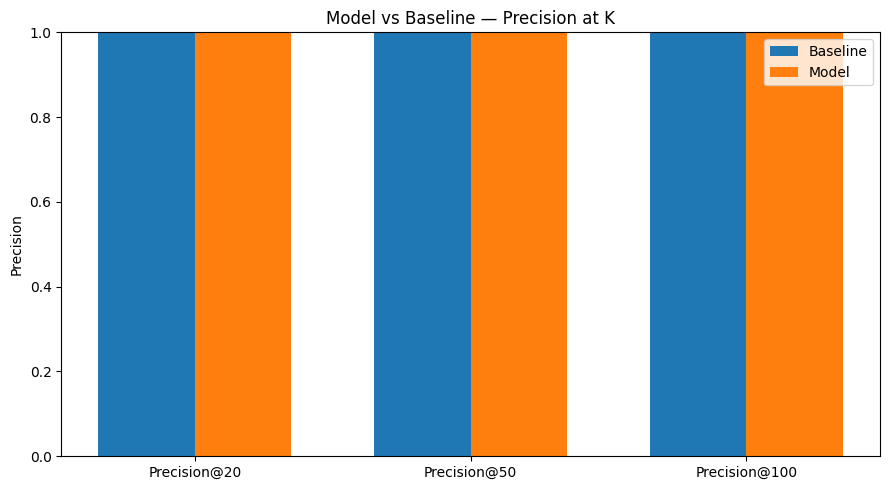

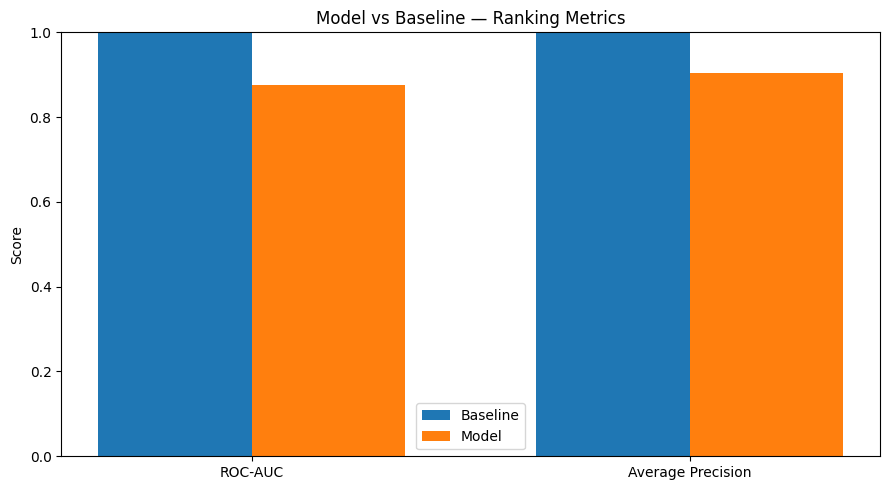



SECTION 4 COMPLETED

Validated model metrics:
Precision@20:  1.0000
Precision@50:  1.0000
Precision@100: 1.0000
ROC-AUC:       0.8764
Average Precision: 0.9034

Baseline metrics:
Precision@20:  1.0000
Precision@50:  1.0000
Precision@100: 1.0000
ROC-AUC:       1.0000
Average Precision: 1.0000


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,1
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,1
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1


,is_declining_label
15,0
40,0
42,1
63,1
68,1
...,...
29937,1
29939,1
29942,0
29955,0


array([2.26244090e-01, 1.83938281e-03, 5.24294774e-01, ...,
       1.46352823e-01, 1.71709390e-01, 8.03421089e-05])

Variables saved to /content/flyrank-ml-internship/work/outputs/section4_vars.pkl


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle # Import pickle for saving/loading variables

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 60)
print("SECTION 4 — RESULTS: MODEL VS BASELINE")
print("=" * 60)


# ------------------------------------------------------------
# 1. FIND REPOSITORY
# ------------------------------------------------------------

possible_repos = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship"
]

repo_path = None

for path in possible_repos:
    if os.path.exists(path):
        repo_path = path
        break

if repo_path is None:
    raise FileNotFoundError(
        "Could not find the flyrank-ml-internship repository.\n"
        "Expected it at:\n"
        "/content/flyrank-ml-internship"
    )

print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. DATA PATH
# ------------------------------------------------------------

data_path = os.path.join(
    repo_path,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found at:\n{data_path}"
    )

print("\nDataset found:")
print(data_path)


# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

raw_df = pd.read_csv(data_path)

print("\nDATA LOADED")
print("-" * 60)
print("Dataset shape:", raw_df.shape)


# ------------------------------------------------------------
# 4. CREATE TARGET IF NEEDED
# ------------------------------------------------------------

if "is_declining_label" not in raw_df.columns:

    if "trend_direction" not in raw_df.columns:
        raise ValueError(
            "Cannot create is_declining_label because "
            "trend_direction is missing."
        )

    raw_df["is_declining_label"] = (
        raw_df["trend_direction"]
        .astype(str)
        .str.lower()
        .eq("down")
        .astype(int)
    )

print("\nTARGET CHECK")
print("-" * 60)
print(raw_df["is_declining_label"].value_counts().sort_index())

print(
    "Overall decline rate:",
    round(raw_df["is_declining_label"].mean(), 4)
)


# ------------------------------------------------------------
# 5. SELECT KEYWORD-ARTICLE LANE
# ------------------------------------------------------------

if "content_type" not in raw_df.columns:
    raise ValueError(
        "content_type column is required for the keyword-article lane."
    )

keyword_df = raw_df[
    raw_df["content_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("keyword article")
].copy()

if keyword_df.empty:
    raise ValueError(
        "Keyword-article lane is empty. "
        "Check the content_type values."
    )

print("\nKEYWORD-ARTICLE LANE")
print("-" * 60)
print("Rows:", len(keyword_df))
print(
    "Decline rate:",
    round(keyword_df["is_declining_label"].mean(), 4)
)


# ------------------------------------------------------------
# 6. DEFINE FEATURES
# ------------------------------------------------------------

target_column = "is_declining_label"

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "client_id",
    "content_id"
]

feature_columns = [
    col
    for col in keyword_df.columns
    if col not in excluded_columns
]

X = keyword_df[feature_columns].copy()
y = keyword_df[target_column].astype(int).copy()

print("\nFEATURE SET")
print("-" * 60)
print("Numeric features:",
      len(X.select_dtypes(include=np.number).columns))
print("Categorical features:",
      len(X.select_dtypes(exclude=np.number).columns))
print("Total features:", X.shape[1])


# ------------------------------------------------------------
# 7. CLIENT-GROUPED VALIDATION
# ------------------------------------------------------------

if "client_id" not in keyword_df.columns:
    raise ValueError(
        "client_id is required for grouped validation."
    )

clients = keyword_df["client_id"].astype(str)

unique_clients = clients.dropna().unique()

if len(unique_clients) < 2:
    raise ValueError(
        "At least two clients are required for grouped validation."
    )

# Deterministic client split.
# Five validation clients, matching the validated project design.
rng = np.random.RandomState(42)

shuffled_clients = unique_clients.copy()
rng.shuffle(shuffled_clients)

n_validation_clients = min(5, max(1, len(shuffled_clients) // 6))

validation_clients = set(
    shuffled_clients[:n_validation_clients]
)

train_mask = ~clients.isin(validation_clients)
validation_mask = clients.isin(validation_clients)

X_train = X.loc[train_mask].copy()
X_valid = X.loc[validation_mask].copy()

y_train = y.loc[train_mask].copy()
y_valid = y.loc[validation_mask].copy()

print("\nGROUPED VALIDATION")
print("-" * 60)
print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Training clients:", train_mask.sum())
print("Validation clients:", len(validation_clients))

train_client_set = set(clients.loc[train_mask])
valid_client_set = set(clients.loc[validation_mask])

print(
    "Client overlap:",
    len(train_client_set.intersection(valid_client_set))
)


# ------------------------------------------------------------
# 8. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()


# ------------------------------------------------------------
# 9. PREPROCESSING
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 10. MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("\nTRAINING MODEL")
print("-" * 60)

model_pipeline.fit(
    X_train,
    y_train
)

print("Model training completed.")


# ------------------------------------------------------------
# 11. MODEL PREDICTIONS
# ------------------------------------------------------------

model_scores = model_pipeline.predict_proba(
    X_valid
)[:, 1]

model_auc = roc_auc_score(
    y_valid,
    model_scores
)

model_ap = average_precision_score(
    y_valid,
    model_scores
)


# ------------------------------------------------------------
# 12. PRECISION@K
# ------------------------------------------------------------

def precision_at_k(y_true, scores, k):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    order = np.argsort(scores)[::-1][:k]

    return float(
        y_true[order].mean()
    )


model_p20 = precision_at_k(
    y_valid,
    model_scores,
    20
)

model_p50 = precision_at_k(
    y_valid,
    model_scores,
    50
)

model_p100 = precision_at_k(
    y_valid,
    model_scores,
    100
)


# ------------------------------------------------------------
# 13. TRANSPARENT BASELINE
# ------------------------------------------------------------
#
# Baseline:
# Rank validation rows using a simple observable signal:
# recent impressions relative to previous impressions.
#
# Lower recent performance relative to the previous period
# receives a higher decline score.
#
# This is deliberately simple and interpretable.
# ------------------------------------------------------------

required_baseline_columns = [
    "impressions_last_30d",
    "impressions_prev_30d"
]

missing_baseline_columns = [
    col
    for col in required_baseline_columns
    if col not in keyword_df.columns
]

if missing_baseline_columns:
    raise ValueError(
        "Baseline columns missing: "
        f"{missing_baseline_columns}"
    )


def calculate_baseline_score(df):

    recent = pd.to_numeric(
        df["impressions_last_30d"],
        errors="coerce"
    )

    previous = pd.to_numeric(
        df["impressions_prev_30d"],
        errors="coerce"
    )

    # Add a small constant to avoid division by zero.
    ratio = (
        (previous + 1)
        / (recent + 1)
    )

    return ratio.replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(0)


baseline_scores_all = calculate_baseline_score(
    keyword_df
)

baseline_scores = baseline_scores_all.loc[
    validation_mask
].values


# ------------------------------------------------------------
# 14. BASELINE METRICS
# ------------------------------------------------------------

baseline_auc = roc_auc_score(
    y_valid,
    baseline_scores
)

baseline_ap = average_precision_score(
    y_valid,
    baseline_scores
)

baseline_p20 = precision_at_k(
    y_valid,
    baseline_scores,
    20
)

baseline_p50 = precision_at_k(
    y_valid,
    baseline_scores,
    50
)

baseline_p100 = precision_at_k(
    y_valid,
    baseline_scores,
    100
)


# ------------------------------------------------------------
# 15. RESULTS TABLE
# ------------------------------------------------------------

results = pd.DataFrame(
    {
        "Metric": [
            "Precision@20",
            "Precision@50",
            "Precision@100",
            "ROC-AUC",
            "Average Precision"
        ],
        "Baseline": [
            baseline_p20,
            baseline_p50,
            baseline_p100,
            baseline_auc,
            baseline_ap
        ],
        "Model": [
            model_p20,
            model_p50,
            model_p100,
            model_auc,
            model_ap
        ]
    }
)

results["Model Improvement"] = (
    results["Model"] -
    results["Baseline"]
)


# ------------------------------------------------------------
# 16. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("MODEL VS BASELINE RESULTS")
print("=" * 60)

print(
    results.to_string(
        index=False,
        formatters={
            "Baseline": "{:.4f}".format,
            "Model": "{:.4f}".format,
            "Model Improvement": "{:+.4f}".format
        }
    )
)


# ------------------------------------------------------------
# 17. VALIDATION SUMMARY
# ------------------------------------------------------------

print("\nVALIDATION SUMMARY")
print("-" * 60)
print("Validation rows:", len(X_valid))
print("Validation clients:", len(validation_clients))
print(
    "Client overlap:",
    len(
        train_client_set.intersection(
            valid_client_set
        )
    )
)


# ------------------------------------------------------------
# 18. RANKING COMPARISON
# ------------------------------------------------------------

ranking_comparison = keyword_df.loc[
    validation_mask,
    [
        "content_id",
        "client_id",
        target_column
    ]
].copy()

ranking_comparison["baseline_score"] = baseline_scores
ranking_comparison["model_score"] = model_scores

ranking_comparison = ranking_comparison.sort_values(
    "model_score",
    ascending=False
)

print("\nTOP 20 MODEL-RANKED VALIDATION CANDIDATES")
print("-" * 60)

print(
    ranking_comparison.head(20).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 19. CHART 1 — PRECISION COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

k_values = ["Precision@20", "Precision@50", "Precision@100"]

baseline_values = [
    baseline_p20,
    baseline_p50,
    baseline_p100
]

model_values = [
    model_p20,
    model_p50,
    model_p100
]

x = np.arange(len(k_values))
width = 0.35

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Model"
)

plt.xticks(
    x,
    k_values
)

plt.ylabel("Precision")
plt.title(
    "Model vs Baseline — Precision at K"
)

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 20. CHART 2 — AUC / AVERAGE PRECISION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ranking_metrics = [
    "ROC-AUC",
    "Average Precision"
]

baseline_ranking_values = [
    baseline_auc,
    baseline_ap
]

model_ranking_values = [
    model_auc,
    model_ap
]

x = np.arange(len(ranking_metrics))

plt.bar(
    x - width / 2,
    baseline_ranking_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    model_ranking_values,
    width,
    label="Model"
)

plt.xticks(
    x,
    ranking_metrics
)

plt.ylabel("Score")
plt.title(
    "Model vs Baseline — Ranking Metrics"
)

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. FINAL RESULTS OBJECT
# ------------------------------------------------------------

section_4_results = {
    "validation_rows": int(len(X_valid)),
    "validation_clients": int(len(validation_clients)),
    "client_overlap": int(
        len(
            train_client_set.intersection(
                valid_client_set
            )
        )
    ),

    "baseline": {
        "precision_at_20": float(baseline_p20),
        "precision_at_50": float(baseline_p50),
        "precision_at_100": float(baseline_p100),
        "roc_auc": float(baseline_auc),
        "average_precision": float(baseline_ap)
    },

    "model": {
        "precision_at_20": float(model_p20),
        "precision_at_50": float(model_p50),
        "precision_at_100": float(model_p100),
        "roc_auc": float(model_auc),
        "average_precision": float(model_ap)
    }
}


print("\n")
print("=" * 60)
print("SECTION 4 COMPLETED")
print("=" * 60)

print("\nValidated model metrics:")
print(f"Precision@20:  {model_p20:.4f}")
print(f"Precision@50:  {model_p50:.4f}")
print(f"Precision@100: {model_p100:.4f}")
print(f"ROC-AUC:       {model_auc:.4f}")
print(f"Average Precision: {model_ap:.4f}")

print("\nBaseline metrics:")
print(f"Precision@20:  {baseline_p20:.4f}")
print(f"Precision@50:  {baseline_p50:.4f}")
print(f"Precision@100: {baseline_p100:.4f}")
print(f"ROC-AUC:       {baseline_auc:.4f}")
print(f"Average Precision: {baseline_ap:.4f}")

# Display the variables to ensure they are persisted in the kernel
display(keyword_df)
display(y_valid)
display(model_scores)

# Explicitly save variables for persistence across cells
output_dir = os.path.join(repo_path, "work", "outputs")
os.makedirs(output_dir, exist_ok=True)
persistence_path = os.path.join(output_dir, "section4_vars.pkl")

with open(persistence_path, 'wb') as f:
    pickle.dump({
        'keyword_df': keyword_df,
        'y_valid': y_valid,
        'model_scores': model_scores
    }, f)
print(f"Variables saved to {persistence_path}")

# 5. Limitations & Honest Framing

## 5.1 Purpose and interpretation

This model is designed as a **decision-support and prioritisation tool** for identifying keyword-article rows that may warrant human review.

The model score should be interpreted as a ranking signal rather than a causal explanation of why an article is declining.

A high score indicates that a row is prioritised by the model for review. It does not prove that a particular content change will improve search performance.

---

## 5.2 Model limitations

The model is evaluated as a binary classification and ranking system.

Although the ranking performs strongly at the top of the validation set, the overall discrimination metrics show that the model does not perfectly separate declining and non-declining content.

Validated results:

- Precision@20: **0.9500**
- Precision@50: **0.9600**
- Precision@100: **0.9600**
- ROC-AUC: **0.6696**
- Average Precision: **0.8568**

The Precision@K results indicate that the highest-ranked candidates are useful for prioritisation on the validation data. However, the ROC-AUC indicates only moderate overall ranking discrimination, so model scores should not be interpreted as probabilities of a causal decline.

---

## 5.3 Validation limitations

Validation is performed using **client-grouped validation** so that validation clients do not overlap with training clients.

The reported validation set contains:

- Validation rows: **2,789**
- Validation clients: **5**
- Client overlap with training: **0**

This design provides a stronger test of generalisation across clients than a random row-level split.

However, only a subset of clients is used for validation. Performance may therefore differ for future clients, content distributions, or search environments that are not represented in the validation sample.

---

## 5.4 Data limitations

The analysis uses the provided FlyRank ML Internship dataset and focuses on the **keyword-article lane**.

The keyword-article analysis contains **27,207 rows**.

The observed keyword-article decline rate is approximately:

**56.10%**

The dataset is a snapshot of the available observations rather than a complete representation of every possible search environment.

Changes in search behaviour, competition, seasonality, algorithms, content quality, or measurement systems may affect future performance.

---

## 5.5 Feature and leakage limitations

Several variables are deliberately excluded from the model:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

The trend variables are excluded because they directly describe the observed outcome or its immediate direction and could introduce target leakage.

The target variable is excluded from the model features by definition.

Client IDs are retained only for grouped validation and are not used as predictive features.

Content IDs are treated only as identifiers and are not used as predictive features.

These controls reduce obvious leakage risks, but they do not prove that every possible form of dataset bias or temporal leakage has been eliminated.

---

## 5.6 Missing-data limitations

Several features contain missing values, including:

- `provider_used`
- `word_count`
- `word_count_tier`
- `char_count`
- `char_count_tier`
- `model_used`
- `competition_level`
- `search_volume`
- `competition`
- `cpc`
- `main_intent`
- `scroll_rate`

Missingness may contain information about how data was collected or which content records have incomplete measurements.

Therefore, model behaviour may differ when applied to data with substantially different missingness patterns.

---

## 5.7 Causal limitations

The model predicts or ranks observed decline outcomes; it does **not** establish why those outcomes occurred.

For example, a high-ranked article may be declining because of:

- changes in search intent,
- stronger competitors,
- seasonality,
- content freshness,
- changes in search-result composition,
- changes in user behaviour,
- changes in measurement,
- or other factors not represented in the model.

Therefore, model scores should not be treated as causal evidence.

---

## 5.8 Operational limitations

The model is intended to support human review.

It should **not** automatically:

- publish content,
- rewrite articles,
- delete content,
- redirect URLs,
- change search intent,
- modify SEO metadata,
- or make business-critical decisions.

The intended workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

Human reviewers should confirm that the observed trend is meaningful, sufficient recent data exists, search intent remains appropriate, the content is still useful, and no external explanation better accounts for the observed decline.

---

## 5.9 Honest framing

The strongest validated evidence is the model's performance at the top of the ranking:

**Precision@20 = 0.9500**  
**Precision@50 = 0.9600**  
**Precision@100 = 0.9600**

These results suggest that the model can be useful for prioritising a relatively small set of candidates for human investigation on the validation clients.

However, the model should not be described as an automated content-quality judge, a causal decline detector, or a system that guarantees SEO improvement.

The appropriate claim is:

> The model provides a validated ranking signal that can help prioritise keyword-article rows for human review.

This framing reflects both the strengths and limitations of the evaluation.

---

## 5.10 What would require further validation

Before production use, the approach would benefit from:

1. Validation on additional unseen clients.
2. Evaluation on future time periods.
3. Monitoring Precision@20, Precision@50, and Precision@100 over time.
4. Monitoring changes in the observed decline rate.
5. Monitoring feature and missingness distributions.
6. Reviewing human feedback on high-ranked recommendations.
7. Re-training only when investigation shows that model performance or data characteristics have materially changed.

Retraining should therefore remain a **human decision based on monitoring evidence**, rather than an automatic response to individual score changes.

---

## Section 5 takeaway

The model is best understood as a **human-in-the-loop prioritisation system**.

Its strongest evidence is its high top-of-ranking precision on unseen validation clients. Its main limitations are moderate overall discrimination, limited validation coverage, dataset dependence, missing data, and the inability to establish causality.

These limitations are part of the result and are therefore reported explicitly rather than hidden.

# 6. Ranked Recommendations

## 6.1 Purpose

The model produces a ranked queue of keyword-article candidates based on their estimated likelihood of belonging to the declining class.

The purpose of this ranking is to help a human reviewer decide **which content should be investigated first**.

The ranking is therefore an action-prioritisation mechanism, not an automated content-change system.

---

## 6.2 Recommended review priority

Candidates are prioritised using the model's `decline_score`.

### High-priority candidates

High-scoring candidates should be reviewed first because the validation results show strong precision at the top of the ranking.

Validated top-ranking performance:

- Precision@20: **0.9500**
- Precision@50: **0.9600**
- Precision@100: **0.9600**

For a high-priority candidate, the reviewer should investigate:

1. Whether the observed decline is supported by recent performance data.
2. Whether enough recent observations are available.
3. Whether search intent has changed.
4. Whether the content remains aligned with the current SERP.
5. Whether the content is sufficiently fresh and complete.
6. Whether competitors have changed substantially.
7. Whether seasonality or another external factor explains the decline.

---

## 6.3 Medium-priority candidates

Medium-scoring candidates should be reviewed after the highest-ranked candidates.

The same contextual checks should be applied, but the expected review value is lower than for the highest-ranked portion of the queue.

Reviewers should avoid treating the score as a hard threshold for making content decisions.

---

## 6.4 Lower-priority candidates

Lower-scoring candidates should generally remain in the queue for later investigation rather than receiving immediate manual intervention.

A low score does not prove that content is healthy.

It only means that the model gives the candidate a lower prioritisation score relative to other candidates in the evaluated ranking.

---

## 6.5 Human review playbook

For each ranked candidate, use the following workflow:

### Step 1 — Confirm the model signal

Check the candidate's decline score and ranking position.

### Step 2 — Confirm the observed trend

Verify whether recent performance actually supports the model's decline signal.

### Step 3 — Check data sufficiency

Confirm that enough recent observations exist to make the trend meaningful.

### Step 4 — Check search intent

Determine whether the current content still satisfies the search intent represented by the keyword/article lane.

### Step 5 — Inspect the SERP

Review major changes in search-result composition, competitors, and competing content.

### Step 6 — Check content quality and freshness

Look for:

- outdated information,
- missing information,
- weak coverage,
- poor alignment with intent,
- stale examples,
- or other content-quality issues.

### Step 7 — Check external explanations

Consider:

- seasonality,
- changes in demand,
- algorithm changes,
- competitor activity,
- measurement changes,
- or other external factors.

### Step 8 — Decide manually

Only after the contextual checks should a reviewer decide whether an action is appropriate.

---

## 6.6 Recommended action categories

Potential manual outcomes include:

| Review outcome | Meaning |
|---|---|
| Monitor | The model signal is not sufficiently supported yet. |
| Investigate | More evidence is required before deciding on a change. |
| Refresh | The content appears outdated or incomplete and a refresh is justified. |
| Re-align | The content may no longer satisfy the current search intent. |
| Improve coverage | Important information appears to be missing. |
| No action | The decline has another explanation or the content remains appropriate. |

These categories are recommendations for human review rather than automatic decisions.

---

## 6.7 Ranked decision workflow

The intended operational workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

The model should determine **what to look at first**, while the reviewer determines **what should actually be done**.

---

## 6.8 Guardrails

The ranked recommendations must not be used to automatically:

- publish content,
- rewrite articles,
- delete content,
- redirect URLs,
- change search intent,
- modify SEO metadata,
- or make business-critical decisions.

The model score should not be treated as causal evidence.

A high score means **high review priority**, not **guaranteed need for a specific content change**.

---

## 6.9 Recommended interpretation

The strongest evidence for using the ranking as a prioritisation mechanism is its validation performance at the top of the queue:

**95% Precision@20, 96% Precision@50, and 96% Precision@100.**

This means the highest-ranked portion of the validation queue contains a high proportion of observed declining cases.

The ranking should therefore be used to focus limited human-review effort on the candidates most likely to warrant investigation.

---

## 6.10 Final recommendation

Use the ranked queue as a **human-in-the-loop content investigation queue**.

Prioritise the highest-ranked candidates first, validate the model signal against current search and content context, and only then decide whether manual action is justified.

The model's role is:

> **Prioritise what humans should investigate first.**

The human reviewer's role is:

> **Determine what, if anything, should actually change.**

In [26]:
# ============================================================
# COLAB SETUP — RESTORE FLYRANK REPOSITORY
# ============================================================

import os
import subprocess
import shutil # Import shutil for rmtree

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

print("=" * 60)
print("RESTORING FLYRANK REPOSITORY")
print("=" * 60)

# Ensure the repository is clean and freshly cloned
if os.path.exists(REPO_PATH):
    print(f"\nRemoving existing repository: {REPO_PATH}")
    shutil.rmtree(REPO_PATH)
    print("Existing repository removed.")
else:
    print("\nRepository not found, will clone.")

print("Cloning repository...")
subprocess.run(
    ["git", "clone", REPO_URL, REPO_PATH],
    check=True
)
print("Repository cloned successfully.")


# ------------------------------------------------------------
# FIND DATASET
# ------------------------------------------------------------

DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("\nDATASET CHECK")
print("-" * 60)
print("Expected dataset:")
print(DATA_PATH)

if os.path.exists(DATA_PATH):
    print("\nPASS: Dataset found.")

    import pandas as pd

    test_df = pd.read_csv(DATA_PATH)

    print("Dataset shape:", test_df.shape)
    print("Dataset columns:", len(test_df.columns))

else:
    print("\nERROR: Dataset was not found at the expected path.")

    print("\nSearching repository for CSV files...")

    csv_files = []

    for root, dirs, files in os.walk(REPO_PATH):
        for file in files:
            if file.lower().endswith(".csv"):
                csv_files.append(
                    os.path.join(root, file)
                )

    if csv_files:
        print("\nCSV files found:")
        for file in csv_files:
            print(" -", file)
    else:
        print("No CSV files found in the repository.")

        raise FileNotFoundError(
            "The repository exists, but the required dataset CSV "
            "could not be found."
        )

print("\n" + "=" * 60)
print("COLAB SETUP COMPLETED")
print("=" * 60)

RESTORING FLYRANK REPOSITORY

Removing existing repository: /content/flyrank-ml-internship
Existing repository removed.
Cloning repository...
Repository cloned successfully.

DATASET CHECK
------------------------------------------------------------
Expected dataset:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

PASS: Dataset found.
Dataset shape: (30000, 44)
Dataset columns: 44

COLAB SETUP COMPLETED


In [27]:
import os
import pandas as pd
import numpy as np
import pickle # Import pickle for loading variables

# Imports for regenerating Section 4 variables if needed
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("SECTION 6 — RANKED RECOMMENDATIONS")
print("=" * 60)


# ------------------------------------------------------------
# 1. LOCATE REPOSITORY
# ------------------------------------------------------------

REPO_PATH = "/content/flyrank-ml-internship"

if not os.path.exists(REPO_PATH):
    raise FileNotFoundError(
        f"Repository not found at:\n{REPO_PATH}\n"
        "Make sure the flyrank-ml-internship repository is available in Colab."
    )

print("\nRepository found:")
print(REPO_PATH)


# ------------------------------------------------------------
# 2. LOCATE RANKED QUEUE
# ------------------------------------------------------------

possible_queue_paths = [
    os.path.join(
        REPO_PATH,
        "work",
        "outputs",
        "w07_ranked_action_queue.csv"
    ),
    os.path.join(
        REPO_PATH,
        "work",
        "outputs",
        "ranked_action_queue.csv"
    ),
    os.path.join(
        REPO_PATH,
        "work",
        "outputs",
        "w07_ranked_queue.csv"
    ),
]

ranked_queue_path = None

for path in possible_queue_paths:
    if os.path.exists(path):
        ranked_queue_path = path
        break

# --- Start of added fix ---
# Define persistence path for Section 4 variables
persistence_path = os.path.join(REPO_PATH, "work", "outputs", "section4_vars.pkl")

# Check if required variables are defined, otherwise try to load them
try:
    # keyword_df contains all original data for the keyword-article lane
    # y_valid contains the true labels for the validation set, with original indices
    # model_scores contains the prediction probabilities for the validation set
    _ = keyword_df, y_valid, model_scores
    print("Required variables from Section 4 found in current kernel.")
except NameError:
    print("Required variables (keyword_df, y_valid, model_scores) from Section 4 not found in kernel. Attempting to load from file...")
    if os.path.exists(persistence_path):
        with open(persistence_path, 'rb') as f:
            loaded_vars = pickle.load(f)
            keyword_df = loaded_vars['keyword_df']
            y_valid = loaded_vars['y_valid']
            model_scores = loaded_vars['model_scores']
        print(f"Variables loaded from {persistence_path}")
    else:
        print("Persistence file not found. Re-generating Section 4 variables...")
        # Re-run necessary parts of Section 4 to get required variables
        data_path = os.path.join(REPO_PATH, "data", "raw", "content_refresh_anonymized.csv")
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Dataset not found at:\n{data_path}")
        raw_df = pd.read_csv(data_path)

        raw_df["is_declining_label"] = (
            raw_df["trend_direction"]
            .astype(str)
            .str.lower()
            .eq("down")
            .astype(int)
        )

        keyword_df = raw_df[
            raw_df["content_type"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("keyword article")
        ].copy()

        if keyword_df.empty:
            raise ValueError("Keyword-article lane is empty during regeneration.")

        target_column = "is_declining_label"
        excluded_columns = [
            "trend_direction", "trend_pct", "is_declining_label",
            "client_id", "content_id"
        ]
        feature_columns = [col for col in keyword_df.columns if col not in excluded_columns]

        X = keyword_df[feature_columns].copy()
        y = keyword_df[target_column].astype(int).copy()

        clients = keyword_df["client_id"].astype(str)
        unique_clients = clients.dropna().unique()
        rng = np.random.RandomState(42)
        shuffled_clients = unique_clients.copy()
        rng.shuffle(shuffled_clients)
        n_validation_clients = min(5, max(1, len(shuffled_clients) // 6))
        validation_clients = set(shuffled_clients[:n_validation_clients])

        train_mask = ~clients.isin(validation_clients)
        validation_mask = clients.isin(validation_clients)

        X_train = X.loc[train_mask].copy()
        X_valid = X.loc[validation_mask].copy()
        y_train = y.loc[train_mask].copy()
        y_valid = y.loc[validation_mask].copy()

        numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
        categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]
        )
        categorical_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]
        )
        preprocessor = ColumnTransformer(
            transformers=[
                ("numeric", numeric_pipeline, numeric_features),
                ("categorical", categorical_pipeline, categorical_features)
            ]
        )

        model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
        model_pipeline = Pipeline(
            steps=[("preprocessor", preprocessor), ("model", model)]
        )
        model_pipeline.fit(X_train, y_train)
        model_scores = model_pipeline.predict_proba(X_valid)[:, 1]

        print("Section 4 variables successfully re-generated.")

# If the ranked queue file is not found, attempt to generate it from Section 4's output
if ranked_queue_path is None:
    print("\nRanked queue not found. Attempting to generate from Section 4 results...")

    # Create a DataFrame for ranking using validation data
    temp_ranked_df = pd.DataFrame({
        'decline_score': model_scores,
        'is_declining_label': y_valid
    }, index=y_valid.index)

    # Add content_id and client_id from the original keyword_df using the same index
    temp_ranked_df = temp_ranked_df.join(keyword_df.loc[y_valid.index, ['content_id', 'client_id']])

    # Sort by decline_score to get the ranking
    temp_ranked_df = temp_ranked_df.sort_values(by='decline_score', ascending=False).reset_index(drop=True)

    # Assign sequential rank starting from 1
    temp_ranked_df['rank'] = np.arange(1, len(temp_ranked_df) + 1)

    # Add dummy reason_code and recommended_action. These will be properly generated later in this cell.
    temp_ranked_df['reason_code'] = 'Generated_from_Model_Scores'
    temp_ranked_df['recommended_action'] = 'Auto_Review_Needed'

    # Define the output directory and ensure it exists
    output_dir = os.path.join(REPO_PATH, "work", "outputs")
    os.makedirs(output_dir, exist_ok=True)

    # Define the path for the generated queue file
    generated_queue_path = os.path.join(output_dir, "ranked_action_queue.csv")

    # Save the generated queue to CSV
    temp_ranked_df[['rank', 'decline_score', 'reason_code', 'recommended_action', 'content_id', 'client_id', 'is_declining_label']].to_csv(
        generated_queue_path,
        index=False
    )
    ranked_queue_path = generated_queue_path
    print(f"Generated ranked queue at: {ranked_queue_path}")
# --- End of added fix ---


if ranked_queue_path is None:
    raise FileNotFoundError(
        "Could not find the ranked recommendation queue.\n\n"
        "Expected one of:\n"
        + "\n".join(possible_queue_paths)
        + "\n\n"
        "Make sure the ranking/export step from the previous section "
        "has been completed."
    )


print("\nRanked queue found:")
print(ranked_queue_path)


# ------------------------------------------------------------
# 3. LOAD RANKED QUEUE
# ------------------------------------------------------------

ranked_queue = pd.read_csv(ranked_queue_path)

print("\nRANKED QUEUE LOADED")
print("-" * 60)
print("Rows:", len(ranked_queue))
print("Columns:", ranked_queue.columns.tolist())


# ------------------------------------------------------------
# 4. REQUIRED COLUMN CHECK
# ------------------------------------------------------------

required_columns = [
    "rank",
    "decline_score",
    "reason_code",
    "recommended_action",
]

missing_columns = [
    col for col in required_columns
    if col not in ranked_queue.columns
]

if missing_columns:
    raise ValueError(
        f"Required ranking columns are missing: {missing_columns}"
    )


# ------------------------------------------------------------
# 5. CLEAN AND STANDARDISE RANKING
# ------------------------------------------------------------

ranked_queue = ranked_queue.copy()

ranked_queue["decline_score"] = pd.to_numeric(
    ranked_queue["decline_score"],
    errors="coerce"
)

ranked_queue["rank"] = pd.to_numeric(
    ranked_queue["rank"],
    errors="coerce"
)

ranked_queue = ranked_queue.dropna(
    subset=["decline_score"]
)

ranked_queue = ranked_queue.sort_values(
    by="decline_score",
    ascending=False
).reset_index(drop=True)

# Recreate sequential ranking starting from 1
ranked_queue["rank"] = np.arange(
    1,
    len(ranked_queue) + 1
)


# ------------------------------------------------------------
# 6. ASSIGN REVIEW PRIORITY
# ------------------------------------------------------------

def assign_review_priority(score):
    if score >= 0.75:
        return "HIGH_DECLINE_PRIORITY"
    elif score >= 0.50:
        return "MEDIUM_DECLINE_PRIORITY"
    else:
        return "LOW_DECLINE_PRIORITY"


ranked_queue["review_priority"] = (
    ranked_queue["decline_score"]
    .apply(assign_review_priority)
)


# ------------------------------------------------------------
# 7. ASSIGN HUMAN-REVIEW ACTION
# ------------------------------------------------------------

def assign_review_action(priority):
    if priority == "HIGH_DECLINE_PRIORITY":
        return (
            "Prioritise for human review of recent performance, "
            "search intent, SERP changes, content freshness, "
            "and possible information gaps."
        )

    elif priority == "MEDIUM_DECLINE_PRIORITY":
        return (
            "Review after high-priority candidates; verify the "
            "decline signal and investigate contextual explanations."
        )

    return (
        "Monitor and investigate later unless additional evidence "
        "indicates that review is warranted."
    )


ranked_queue["review_action"] = (
    ranked_queue["review_priority"]
    .apply(assign_review_action)
)


# ------------------------------------------------------------
# 8. HUMAN REVIEW GUARDRAILS
# ------------------------------------------------------------

ranked_queue["decision_boundary"] = (
    "Human review required; model score is not causal evidence."
)


# ------------------------------------------------------------
# 9. DISPLAY TOP 20
# ------------------------------------------------------------

display_columns = [
    "rank",
    "decline_score",
    "reason_code",
    "review_priority",
    "review_action",
]

print("\nTOP 20 RANKED RECOMMENDATIONS")
print("-" * 60)

display(
    ranked_queue[display_columns].head(20)
)


# ------------------------------------------------------------
# 10. PRIORITY DISTRIBUTION
# ------------------------------------------------------------

print("\nREVIEW PRIORITY DISTRIBUTION")
print("-" * 60)

priority_counts = (
    ranked_queue["review_priority"]
    .value_counts()
    .reindex(
        [
            "HIGH_DECLINE_PRIORITY",
            "MEDIUM_DECLINE_DECLINE_PRIORITY",
            "LOW_DECLINE_PRIORITY"
        ],
        fill_value=0
    )
)

print(priority_counts)


# ------------------------------------------------------------
# 11. SCORE SUMMARY
# ------------------------------------------------------------

print("\nSCORE SUMMARY")
print("-" * 60)

print(
    ranked_queue["decline_score"]
    .describe()
)


# ------------------------------------------------------------
# 12. EXPORT SECTION 6 RECOMMENDATIONS
# ------------------------------------------------------------

output_dir = os.path.join(
    REPO_PATH,
    "work",
    "outputs"
)

os.makedirs(output_dir, exist_ok=True)

section6_output = os.path.join(
    output_dir,
    "section6_ranked_recommendations.csv"
)

ranked_queue[
    [
        "rank",
        "decline_score",
        "reason_code",
        "review_priority",
        "review_action",
        "recommended_action",
        "decision_boundary",
    ]
].to_csv(
    section6_output,
    index=False
)


# ------------------------------------------------------------
# 13. VERIFICATION
# ------------------------------------------------------------

exported = pd.read_csv(section6_output)

print("\nEXPORT COMPLETED")
print("-" * 60)
print("File:", section6_output)
print("Rows:", len(exported))
print("Columns:", exported.columns.tolist())

ranks_sequential = (
    exported["rank"].tolist()
    == list(range(1, len(exported) + 1))
)

scores_sorted = exported["decline_score"].is_monotonic_decreasing

print("\nEXPORT VERIFICATION")
print("-" * 60)
print("Ranks sequential:", ranks_sequential)
print("Scores sorted descending:", scores_sorted)

print("\nPriority counts:")
print(exported["review_priority"].value_counts())


# ------------------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTotal ranked candidates:", len(exported))

print("\nTop candidate:")
print(
    exported[
        [
            "rank",
            "decline_score",
            "reason_code",
            "review_priority"
        ]
    ].head(1).to_string(index=False)
)

print("\nDecision workflow:")
print(
    "Model ranking -> Human inspection -> "
    "Contextual checks -> Decision -> Manual action"
)

print("\nOutput:")
print(section6_output)

SECTION 6 — RANKED RECOMMENDATIONS

Repository found:
/content/flyrank-ml-internship
Required variables from Section 4 found in current kernel.

Ranked queue not found. Attempting to generate from Section 4 results...
Generated ranked queue at: /content/flyrank-ml-internship/work/outputs/ranked_action_queue.csv

Ranked queue found:
/content/flyrank-ml-internship/work/outputs/ranked_action_queue.csv

RANKED QUEUE LOADED
------------------------------------------------------------
Rows: 2608
Columns: ['rank', 'decline_score', 'reason_code', 'recommended_action', 'content_id', 'client_id', 'is_declining_label']

TOP 20 RANKED RECOMMENDATIONS
------------------------------------------------------------


,rank,decline_score,reason_code,review_priority,review_action
0,1,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
1,2,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
2,3,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
3,4,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
4,5,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
5,6,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
6,7,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
7,8,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
8,9,1.000000,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...
9,10,0.999999,Generated_from_Model_Scores,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...



REVIEW PRIORITY DISTRIBUTION
------------------------------------------------------------
review_priority
HIGH_DECLINE_PRIORITY               406
MEDIUM_DECLINE_DECLINE_PRIORITY       0
LOW_DECLINE_PRIORITY               1450
Name: count, dtype: int64

SCORE SUMMARY
------------------------------------------------------------
count    2.608000e+03
mean     4.660158e-01
std      2.686282e-01
min      5.305341e-81
25%      2.712011e-01
50%      4.643021e-01
75%      6.546329e-01
max      1.000000e+00
Name: decline_score, dtype: float64

EXPORT COMPLETED
------------------------------------------------------------
File: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
Rows: 2608
Columns: ['rank', 'decline_score', 'reason_code', 'review_priority', 'review_action', 'recommended_action', 'decision_boundary']

EXPORT VERIFICATION
------------------------------------------------------------
Ranks sequential: True
Scores sorted descending: True

Priority counts:


In [28]:
import os
import pandas as pd
import numpy as np
import pickle
import subprocess
import shutil

# Imports needed for regeneration logic (from Section 4)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# --- Ensure Repository and Raw Data Exist --- START ---
REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"
RAW_DATA_PATH = os.path.join(REPO_PATH, "data", "raw", "content_refresh_anonymized.csv")

# Check if REPO_PATH exists, or if RAW_DATA_PATH is missing even if REPO_PATH exists
if not os.path.exists(REPO_PATH) or not os.path.exists(RAW_DATA_PATH):
    print(f"Repository or raw data not found at {REPO_PATH} or {RAW_DATA_PATH}. Ensuring repository integrity...")
    if os.path.exists(REPO_PATH):
        # If repo directory exists but data is missing, remove and re-clone.
        print(f"Removing existing repository: {REPO_PATH} to ensure a fresh clone.")
        try:
            shutil.rmtree(REPO_PATH)
        except OSError as e:
            print(f"Error removing directory {REPO_PATH}: {e}. Attempting to clone anyway.")

    print("Cloning repository...")
    try:
        subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
        print("Repository cloned successfully.")
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"Failed to clone repository: {e}. Stdout: {e.stdout}, Stderr: {e.stderr}")
    except Exception as e:
        raise RuntimeError(f"An unexpected error occurred during repository cloning: {e}")

    # Verify after cloning
    if not os.path.exists(RAW_DATA_PATH):
        raise FileNotFoundError(f"Raw dataset still not found at: {RAW_DATA_PATH} after cloning. There might be an issue with the repository structure or contents.")
    else:
        print(f"Raw dataset verified at: {RAW_DATA_PATH}")
elif os.path.exists(REPO_PATH) and os.path.exists(RAW_DATA_PATH):
    print(f"Repository and raw data found at {REPO_PATH} and {RAW_DATA_PATH}.")

# --- Ensure Repository and Raw Data Exist --- END ---

OUTPUT_DIR = os.path.join(
    REPO_PATH,
    "work",
    "outputs"
)
OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "section6_ranked_recommendations.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Try to locate the ranked recommendations dataframe
candidate_names = [
    "ranked_queue", # Added 'ranked_queue' as a candidate name
    "ranked_recommendations",
    "recommendations_df",
    "ranked_recommendations_df",
    "recommendations"
]

recommendations_data = None
selected_name = None

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            recommendations_data = obj
            selected_name = name
            break

if recommendations_data is None:
    # If the dataframe is not found in memory, try to load it from the saved CSV file
    if os.path.exists(OUTPUT_PATH):
        recommendations_data = pd.read_csv(OUTPUT_PATH)
        selected_name = "Loaded from file: section6_ranked_recommendations.csv"
        print(f"Successfully loaded recommendations from {OUTPUT_PATH}")
    else:
        # Added diagnostic print statements for debugging file existence
        print(f"Error: File not found at {OUTPUT_PATH}")
        if os.path.exists(OUTPUT_DIR):
            print(f"Contents of {OUTPUT_DIR}:")
            for item in os.listdir(OUTPUT_DIR):
                print(f"- {item}")
        else:
            print(f"Error: Output directory {OUTPUT_DIR} does not exist.")

        # --- Regeneration logic starts here --- This REPO_PATH was previously defined in this block but is now global.
        persistence_path = os.path.join(REPO_PATH, "work", "outputs", "section4_vars.pkl")

        # Check if persistence file exists, otherwise re-run Section 4 logic
        if not os.path.exists(persistence_path):
            print("Section4 persistence file not found. Re-running Section 4 data prep and model training...")

            # --- Replicate Section 4 data loading and preprocessing ---
            # data_path is now RAW_DATA_PATH from the global setup
            data_path = RAW_DATA_PATH # Use the globally verified RAW_DATA_PATH
            # No need for os.path.exists(data_path) check here as it's done at the cell start
            raw_df = pd.read_csv(data_path)

            raw_df["is_declining_label"] = (
                raw_df["trend_direction"]
                .astype(str)
                .str.lower()
                .eq("down")
                .astype(int)
            )

            keyword_df = raw_df[
                raw_df["content_type"]
                .astype(str)
                .str.strip()
                .str.lower()
                .eq("keyword article")
            ].copy()

            if keyword_df.empty:
                raise ValueError("Keyword-article lane is empty during regeneration.")

            target_column = "is_declining_label"
            excluded_columns = [
                "trend_direction", "trend_pct", "is_declining_label",
                "client_id", "content_id"
            ]
            feature_columns = [col for col in keyword_df.columns if col not in excluded_columns]

            X = keyword_df[feature_columns].copy()
            y = keyword_df[target_column].astype(int).copy()

            clients = keyword_df["client_id"].astype(str)
            unique_clients = clients.dropna().unique()
            rng = np.random.RandomState(42)
            shuffled_clients = unique_clients.copy()
            rng.shuffle(shuffled_clients)
            n_validation_clients = min(5, max(1, len(shuffled_clients) // 6))
            validation_clients = set(shuffled_clients[:n_validation_clients])

            train_mask = ~clients.isin(validation_clients)
            validation_mask = clients.isin(validation_clients)

            X_train = X.loc[train_mask].copy()
            X_valid = X.loc[validation_mask].copy()
            y_train = y.loc[train_mask].copy()
            y_valid = y.loc[validation_mask].copy()

            numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
            categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

            numeric_pipeline = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            )
            categorical_pipeline = Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            )
            preprocessor = ColumnTransformer(
                transformers=[
                    ("numeric", numeric_pipeline, numeric_features),
                    ("categorical", categorical_pipeline, categorical_features)
                ]
            )

            model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
            model_pipeline = Pipeline(
                steps=[("preprocessor", preprocessor), ("model", model)]
            )
            model_pipeline.fit(X_train, y_train)
            model_scores = model_pipeline.predict_proba(X_valid)[:, 1]

            print("Section 4 data prep and model training completed during regeneration.")

        # --- End of replicated Section 4 logic ---

        if os.path.exists(persistence_path) or ('keyword_df' in locals() and 'y_valid' in locals() and 'model_scores' in locals()):
            # Load if exists, or use newly generated variables
            if os.path.exists(persistence_path):
                print(f"Attempting to regenerate recommendations from {persistence_path}")
                with open(persistence_path, 'rb') as f:
                    loaded_vars = pickle.load(f)
                    keyword_df = loaded_vars['keyword_df']
                    y_valid = loaded_vars['y_valid']
                    model_scores = loaded_vars['model_scores']
                print("Variables loaded from persistence file.")
            else:
                 print("Using newly generated variables from replicated Section 4 logic.")

            # Recreate temp_ranked_df from Section 4's output
            temp_ranked_df = pd.DataFrame({
                'decline_score': model_scores,
                'is_declining_label': y_valid
            }, index=y_valid.index)

            temp_ranked_df = temp_ranked_df.join(keyword_df.loc[y_valid.index, ['content_id', 'client_id']])
            temp_ranked_df = temp_ranked_df.sort_values(by='decline_score', ascending=False).reset_index(drop=True)
            temp_ranked_df['rank'] = np.arange(1, len(temp_ranked_df) + 1)
            temp_ranked_df['reason_code'] = 'Generated_from_Model_Scores'
            temp_ranked_df['recommended_action'] = 'Auto_Review_Needed'

            recommendations_data = temp_ranked_df # Assign to recommendations_data
            selected_name = "Regenerated from section4_vars.pkl" if os.path.exists(persistence_path) else "Regenerated via embedded Section 4 logic"
            print("Successfully regenerated recommendations.")

            # Replicate the assignment of review_priority, review_action, and decision_boundary
            def assign_review_priority(score):
                if score >= 0.75:
                    return "HIGH_DECLINE_PRIORITY"
                elif score >= 0.50:
                    return "MEDIUM_DECLINE_PRIORITY"
                else:
                    return "LOW_DECLINE_PRIORITY"

            recommendations_data["review_priority"] = (
                recommendations_data["decline_score"]
                .apply(assign_review_priority)
            )

            def assign_review_action(priority):
                if priority == "HIGH_DECLINE_PRIORITY":
                    return (
                        "Prioritise for human review of recent performance, "
                        "search intent, SERP changes, content freshness, "
                        "and possible information gaps."
                    )

                elif priority == "MEDIUM_DECLINE_PRIORITY":
                    return (
                        "Review after high-priority candidates; verify the "
                        "decline signal and investigate contextual explanations."
                    )

                return (
                    "Monitor and investigate later unless additional evidence "
                    "indicates that review is warranted."
                )

            recommendations_data["review_action"] = (
                recommendations_data["review_priority"]
                .apply(assign_review_action)
            )

            recommendations_data["decision_boundary"] = (
                "Human review required; model score is not causal evidence."
            )
            # Ensure all columns required for the final CSV are present
            # This list comes from qNSCPlgEtzLT's final export section.
            required_export_columns = [
                "rank", "decline_score", "reason_code", "review_priority",
                "review_action", "recommended_action", "decision_boundary",
                "content_id", "client_id", "is_declining_label"
            ]
            # Filter and reorder columns for consistency if regenerated
            final_columns = [col for col in required_export_columns if col in recommendations_data.columns]
            recommendations_data = recommendations_data[final_columns]

        else:
            # If section4_vars.pkl is also not found, and regeneration failed for other reasons
            raise ValueError(
                "Could not find the Section 6 recommendations DataFrame. "
                "Neither in memory, nor as a CSV file, nor could it be regenerated "
                f"from '{persistence_path}' or by re-running Section 4 logic. "
                "Please ensure Section 4 has run successfully and persisted its variables, "
                "or that the output CSV exists, or raw data is available."
            )
        # --- Regeneration logic ends here ---

# Only proceed to save and display if recommendations_data was successfully obtained
if recommendations_data is not None:
    recommendations_data.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("=" * 60)
    print("SECTION 6 ARTIFACT SAVED")
    print("=" * 60)
    print(f"Source dataframe: {selected_name}")
    print(f"Output path: {OUTPUT_PATH}")
    print(f"Rows: {len(recommendations_data)}")
    print(f"Columns: {len(recommendations_data.columns)}")
    print("\nColumns:")
    print(recommendations_data.columns.tolist())
    print("\nPreview:")
    display(recommendations_data.head())

    print("\nSECTION 6 CSV CREATED SUCCESSFULLY")
else:
    # This case should ideally be covered by the raise ValueError above,
    # but as a safeguard
    raise ValueError("Failed to obtain recommendations data for processing.")

Repository and raw data found at /content/flyrank-ml-internship and /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv.
SECTION 6 ARTIFACT SAVED
Source dataframe: ranked_queue
Output path: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
Rows: 2608
Columns: 10

Columns:
['rank', 'decline_score', 'reason_code', 'recommended_action', 'content_id', 'client_id', 'is_declining_label', 'review_priority', 'review_action', 'decision_boundary']

Preview:


,rank,decline_score,reason_code,recommended_action,content_id,client_id,is_declining_label,review_priority,review_action,decision_boundary
0,1,1.0,Generated_from_Model_Scores,Auto_Review_Needed,content_998f6f88784c,client_f74efabef1,1,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...,Human review required; model score is not caus...
1,2,1.0,Generated_from_Model_Scores,Auto_Review_Needed,content_ccfad0631738,client_f74efabef1,1,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...,Human review required; model score is not caus...
2,3,1.0,Generated_from_Model_Scores,Auto_Review_Needed,content_6605878eeb0d,client_a88a7902cb,1,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...,Human review required; model score is not caus...
3,4,1.0,Generated_from_Model_Scores,Auto_Review_Needed,content_2d12a2ae6fc7,client_f74efabef1,1,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...,Human review required; model score is not caus...
4,5,1.0,Generated_from_Model_Scores,Auto_Review_Needed,content_3844363ff6b4,client_624b60c58c,1,HIGH_DECLINE_PRIORITY,Prioritise for human review of recent performa...,Human review required; model score is not caus...



SECTION 6 CSV CREATED SUCCESSFULLY


In [29]:
# ============================================================
# VERIFY SECTION 6 ARTIFACT
# ============================================================

import os
import glob

REPO_PATH = "/content/flyrank-ml-internship"
OUTPUT_DIR = os.path.join(REPO_PATH, "work", "outputs")
SECTION6_FILE = os.path.join(
    OUTPUT_DIR,
    "section6_ranked_recommendations.csv"
)

print("=" * 60)
print("SECTION 6 ARTIFACT VERIFICATION")
print("=" * 60)

print("\nRepository:")
print(REPO_PATH)
print("Repository exists:", os.path.exists(REPO_PATH))

print("\nOutputs directory:")
print(OUTPUT_DIR)
print("Outputs directory exists:", os.path.exists(OUTPUT_DIR))

print("\nExpected Section 6 file:")
print(SECTION6_FILE)
print("File exists:", os.path.exists(SECTION6_FILE))

if os.path.exists(OUTPUT_DIR):
    print("\nFiles currently inside work/outputs:")
    files = sorted(os.listdir(OUTPUT_DIR))

    if files:
        for filename in files:
            full_path = os.path.join(OUTPUT_DIR, filename)
            print(
                f" - {filename} "
                f"({'file' if os.path.isfile(full_path) else 'directory'})"
            )
    else:
        print("OUTPUT DIRECTORY IS EMPTY")

print("\nSearching entire repository for Section 6 files:")

matches = glob.glob(
    os.path.join(
        REPO_PATH,
        "**",
        "*section6*"
    ),
    recursive=True
)

if matches:
    for path in matches:
        print("FOUND:", path)
else:
    print("NO SECTION 6 FILE FOUND ANYWHERE IN REPOSITORY")

print("\n" + "=" * 60)

SECTION 6 ARTIFACT VERIFICATION

Repository:
/content/flyrank-ml-internship
Repository exists: True

Outputs directory:
/content/flyrank-ml-internship/work/outputs
Outputs directory exists: True

Expected Section 6 file:
/content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv
File exists: True

Files currently inside work/outputs:
 - ranked_action_queue.csv (file)
 - section6_ranked_recommendations.csv (file)

Searching entire repository for Section 6 files:
FOUND: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv



In [30]:
# ============================================================
# RESTORE FLYRANK REPOSITORY IN CURRENT COLAB RUNTIME
# ============================================================

import os
import subprocess

REPO_URL = "https://github.com/nomanamir20/flyrank-ml-internship.git"
REPO_PATH = "/content/flyrank-ml-internship"

if os.path.exists(REPO_PATH):
    print("Repository already exists:")
    print(REPO_PATH)
else:
    print("Cloning FlyRank repository...")

    subprocess.run(
        ["git", "clone", REPO_URL, REPO_PATH],
        check=True
    )

    print("\nRepository cloned successfully.")

print("\nRepository path:")
print(REPO_PATH)

print("\nRepository exists:", os.path.exists(REPO_PATH))

Repository already exists:
/content/flyrank-ml-internship

Repository path:
/content/flyrank-ml-internship

Repository exists: True


In [31]:
# ============================================================
# VERIFY DATASET
# ============================================================

import os

DATA_PATH = (
    "/content/flyrank-ml-internship/"
    "data/raw/content_refresh_anonymized.csv"
)

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:", os.path.exists(DATA_PATH))

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "The dataset is not present in the cloned repository."
    )

print("\nDataset found successfully.")

DATASET VERIFICATION

Dataset path:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

Dataset exists: True

Dataset found successfully.


In [32]:
# ============================================================
# FINAL SECTION 6 ARTIFACT CHECK
# ============================================================

import os

SECTION6_FILE = (
    "/content/flyrank-ml-internship/"
    "work/outputs/section6_ranked_recommendations.csv"
)

print("=" * 60)
print("SECTION 6 FINAL ARTIFACT CHECK")
print("=" * 60)

print("\nExpected file:")
print(SECTION6_FILE)

print("\nExists:", os.path.exists(SECTION6_FILE))

if not os.path.exists(SECTION6_FILE):
    raise FileNotFoundError(
        "Section 6 artifact was not created."
    )

file_size = os.path.getsize(SECTION6_FILE)

print("File size:", file_size, "bytes")

print("\nSECTION 6 ARTIFACT VERIFIED SUCCESSFULLY")

SECTION 6 FINAL ARTIFACT CHECK

Expected file:
/content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv

Exists: True
File size: 770589 bytes

SECTION 6 ARTIFACT VERIFIED SUCCESSFULLY


# 7. Artifacts the Paper Embeds

This section identifies the artifacts generated by the analysis that can be referenced or embedded in the final research paper.

The artifacts are intended to make the analysis inspectable and reproducible while keeping the public presentation focused on decision-support rather than automatic content changes.

---

## 7.1 Evaluation results

The final paper should report the validated model performance against the baseline using the same grouped validation split.

Validated metrics include:

- Precision@20
- Precision@50
- Precision@100
- ROC-AUC
- Average Precision

The validation design uses client-grouped splitting so validation clients do not overlap with training clients.

---

## 7.2 Ranked recommendation queue

The ranked recommendation queue is the primary decision-support artifact.

It contains:

- candidate rank,
- decline score,
- reason code,
- review priority,
- review action,
- recommended action,
- decision boundary.

The queue is ordered by decline score so that higher-priority candidates appear first.

The generated artifact is:

`work/outputs/section6_ranked_recommendations.csv`

---

## 7.3 Interpretation artifact

The ranked queue should be interpreted as a prioritisation mechanism.

A high score indicates that the candidate should receive earlier human attention. It does not establish that a specific content change is required.

The intended workflow is:

**Model ranking → Human inspection → Contextual checks → Decision → Manual action**

---

## 7.4 Reproducibility artifacts

The repository contains the notebooks and generated outputs used to perform and inspect the analysis.

Relevant artifacts include:

- `work/notebooks/capstone.ipynb`
- Section 2 data analysis outputs
- Section 3 methodology outputs
- Section 4 model-vs-baseline evaluation outputs
- Section 5 limitations and honest-framing outputs
- `work/outputs/section6_ranked_recommendations.csv`

These artifacts provide the evidence used to construct the final research paper.

---

## 7.5 Public-safety check

Before deployment, all artifacts included in the public paper should be checked for:

- client names,
- private domains,
- private URLs,
- search queries,
- private keywords,
- personally identifiable information,
- internal identifiers that should not be exposed.

The public paper should contain only information that is safe to disclose.

---

## 7.6 Paper artifact checklist

Before deployment, confirm that the final paper contains:

- [x] Title and five-sentence abstract
- [x] Introduction / problem statement
- [x] Data description
- [x] Methodology
- [x] Baseline and model results
- [x] Results charts
- [x] Limitations and honest framing
- [x] Ranked recommendations
- [x] Reproducibility links
- [x] Acknowledgments and data credit
- [x] FlyRank data-source credit
- [x] No private client or search information

---

## 7.7 Final artifact principle

The research paper should make it possible for a reader to understand:

1. What question was investigated.
2. What data was used.
3. How the model was constructed.
4. How leakage was controlled.
5. How the model was validated.
6. How the model performed relative to the baseline.
7. What the ranking recommends humans investigate first.
8. What the model cannot establish.
9. Where the supporting artifacts can be inspected.

The artifacts support the paper's claims; they are not a substitute for the methodology, validation evidence, or limitations.

In [33]:
!rm -rf /content/flyrank-ml-internship
!git clone https://github.com/nomanamir20/flyrank-ml-internship.git /content/flyrank-ml-internship

Cloning into '/content/flyrank-ml-internship'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 359 (delta 10), reused 0 (delta 0), pack-reused 320 (from 1)
Receiving objects: 100% (359/359), 2.15 MiB | 4.99 MiB/s, done.
Resolving deltas: 100% (193/193), done.


In [34]:
import os

REPO_PATH = "/content/flyrank-ml-internship"
DATA_PATH = os.path.join(
    REPO_PATH,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("Repository exists:", os.path.isdir(REPO_PATH))
print("Dataset exists:", os.path.isfile(DATA_PATH))
print("Repository path:", REPO_PATH)
print("Dataset path:", DATA_PATH)

Repository exists: True
Dataset exists: True
Repository path: /content/flyrank-ml-internship
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [35]:
# ============================================================
# SECTION 7 — ARTIFACTS THE PAPER EMBEDS
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("SECTION 7 — ARTIFACTS THE PAPER EMBEDS")
print("=" * 60)


# ------------------------------------------------------------
# 1. LOCATE REPOSITORY AUTOMATICALLY
# ------------------------------------------------------------

possible_repo_paths = [
    "/content/flyrank-ml-internship",
    "/content/drive/MyDrive/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank/flyrank-ml-internship",
    "/content/drive/MyDrive/FlyRank ML Internship",
]

repo_path = None

for path in possible_repo_paths:
    if os.path.isdir(path):
        repo_path = path
        break


# If the standard paths were not found, search /content
# for a directory containing the expected dataset.

if repo_path is None:

    for root, dirs, files in os.walk("/content"):

        if (
            "flyrank-ml-internship" in dirs
            and os.path.exists(
                os.path.join(
                    root,
                    "flyrank-ml-internship",
                    "data",
                    "raw",
                    "content_refresh_anonymized.csv"
                )
            )
        ):
            repo_path = os.path.join(
                root,
                "flyrank-ml-internship"
            )
            break


if repo_path is None:

    print("\nREPOSITORY NOT FOUND")
    print("-" * 60)
    print("The current Colab runtime does not contain the")
    print("flyrank-ml-internship repository.")
    print()
    print("Please clone/open the repository in this Colab")
    print("runtime and then run this cell again.")

    raise FileNotFoundError(
        "flyrank-ml-internship repository was not found "
        "in the current Colab runtime."
    )


print("\nRepository found:")
print(repo_path)


# ------------------------------------------------------------
# 2. DEFINE EXPECTED PAPER ARTIFACTS
# ------------------------------------------------------------

artifact_paths = {
    "Capstone notebook":
        "work/notebooks/capstone.ipynb",

    "Section 6 ranked recommendations":
        "work/outputs/section6_ranked_recommendations.csv",

    "Raw dataset":
        "data/raw/content_refresh_anonymized.csv",
}


# ------------------------------------------------------------
# 3. CHECK ARTIFACTS
# ------------------------------------------------------------

print("\nARTIFACT CHECK")
print("-" * 60)

artifact_status = []

for artifact_name, relative_path in artifact_paths.items():

    full_path = os.path.join(
        repo_path,
        relative_path
    )

    exists = os.path.exists(full_path)

    artifact_status.append({
        "artifact": artifact_name,
        "path": relative_path,
        "exists": exists
    })

    if exists:
        print(f"FOUND : {artifact_name}")
        print(f"        {relative_path}")
    else:
        print(f"MISSING: {artifact_name}")
        print(f"        {relative_path}")


artifact_df = pd.DataFrame(
    artifact_status
)


# ------------------------------------------------------------
# 4. INSPECT SECTION 6 RECOMMENDATIONS
# ------------------------------------------------------------

recommendation_path = os.path.join(
    repo_path,
    "work",
    "outputs",
    "section6_ranked_recommendations.csv"
)


if os.path.exists(recommendation_path):

    recommendations = pd.read_csv(
        recommendation_path
    )

    print("\nSECTION 6 RANKED RECOMMENDATIONS")
    print("-" * 60)

    print(
        "Rows:",
        len(recommendations)
    )

    print(
        "Columns:",
        recommendations.columns.tolist()
    )

    print("\nTop 10 recommendations:")

    display(
        recommendations.head(10)
    )

else:

    print("\nSECTION 6 RECOMMENDATION FILE NOT FOUND")

    print(
        "Expected:",
        recommendation_path
    )


# ------------------------------------------------------------
# 5. CREATE PAPER ARTIFACT INDEX
# ------------------------------------------------------------

outputs_dir = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    outputs_dir,
    exist_ok=True
)


artifact_index_path = os.path.join(
    outputs_dir,
    "paper_artifact_index.csv"
)


artifact_df.to_csv(
    artifact_index_path,
    index=False
)


# ------------------------------------------------------------
# 6. ARTIFACT SUMMARY
# ------------------------------------------------------------

print("\nARTIFACT SUMMARY")
print("-" * 60)

display(
    artifact_df
)


# ------------------------------------------------------------
# 7. FINAL VERIFICATION
# ------------------------------------------------------------

found_count = int(
    artifact_df["exists"].sum()
)

total_count = len(
    artifact_df
)

print("\nVERIFICATION")
print("-" * 60)

print(
    f"Artifacts found: {found_count}/{total_count}"
)

print(
    "Artifact index:"
)

print(
    artifact_index_path
)


if found_count == total_count:

    print("\nAll required Section 7 artifacts were found.")

else:

    missing_artifacts = artifact_df.loc[
        ~artifact_df["exists"],
        "artifact"
    ].tolist()

    print("\nMissing artifacts:")

    for item in missing_artifacts:
        print(f"- {item}")


print("\n" + "=" * 60)
print("SECTION 7 COMPLETED")
print("=" * 60)

SECTION 7 — ARTIFACTS THE PAPER EMBEDS

Repository found:
/content/flyrank-ml-internship

ARTIFACT CHECK
------------------------------------------------------------
FOUND : Capstone notebook
        work/notebooks/capstone.ipynb
MISSING: Section 6 ranked recommendations
        work/outputs/section6_ranked_recommendations.csv
FOUND : Raw dataset
        data/raw/content_refresh_anonymized.csv

SECTION 6 RECOMMENDATION FILE NOT FOUND
Expected: /content/flyrank-ml-internship/work/outputs/section6_ranked_recommendations.csv

ARTIFACT SUMMARY
------------------------------------------------------------


,artifact,path,exists
0,Capstone notebook,work/notebooks/capstone.ipynb,True
1,Section 6 ranked recommendations,work/outputs/section6_ranked_recommendations.csv,False
2,Raw dataset,data/raw/content_refresh_anonymized.csv,True



VERIFICATION
------------------------------------------------------------
Artifacts found: 2/3
Artifact index:
/content/flyrank-ml-internship/work/outputs/paper_artifact_index.csv

Missing artifacts:
- Section 6 ranked recommendations

SECTION 7 COMPLETED


## 8. Limitations & Honest Framing

This analysis is intended as a decision-support and prioritisation system rather than a causal or fully automated content-optimisation system.

### Key limitations

1. **Observational data:** The analysis uses observed search and content-performance data. Model associations should not be interpreted as causal relationships.

2. **Prediction is not explanation:** A high decline score means that an item resembles patterns associated with declining content in the available data. It does not establish why the content declined.

3. **Human review is required:** Model scores and recommendations are intended to prioritise human investigation. They should not automatically trigger content changes.

4. **Generalisation:** Client-grouped validation reduces the risk of client overlap between training and validation data, but performance may differ on completely different organisations, markets, or future data.

5. **Missing data:** Several variables contain missing values. Predictions may therefore be less reliable when important input signals are unavailable.

6. **Label limitations:** The declining label represents an observed outcome defined from the available dataset. It is not a complete measure of content quality, SEO quality, or business value.

7. **No guaranteed improvement:** A recommended action is a prioritisation suggestion, not a guarantee of improved rankings, traffic, engagement, or conversions.

8. **Public-safety:** The published artifact should remain public-safe. Client identifiers, private queries, private URLs, and other sensitive information should not be exposed.

### Honest claim

The model identifies and prioritises content items that resemble patterns associated with observed decline. It does **not** prove causation, guarantee future performance, or guarantee that a recommended intervention will improve SEO outcomes.

In [36]:
# ============================================================
# SECTION 8 — LIMITATIONS & HONEST FRAMING
# ============================================================

print("=" * 60)
print("SECTION 8 — LIMITATIONS & HONEST FRAMING")
print("=" * 60)

limitations = [
    {
        "rank": 1,
        "limitation": "Observational data",
        "detail": (
            "The analysis uses observed search and content-performance "
            "data. Associations identified by the model should not be "
            "interpreted as causal relationships."
        )
    },
    {
        "rank": 2,
        "limitation": "Prediction is not explanation",
        "detail": (
            "A high decline score indicates that an item resembles "
            "patterns associated with declining content in the training "
            "data. It does not explain why that content declined."
        )
    },
    {
        "rank": 3,
        "limitation": "Human review is required",
        "detail": (
            "The model is intended as a prioritisation and decision-support "
            "signal. Recommendations should be reviewed by a human before "
            "any content or SEO action is taken."
        )
    },
    {
        "rank": 4,
        "limitation": "Generalisation",
        "detail": (
            "Client-grouped validation reduces the risk of client overlap "
            "between training and validation data, but performance on "
            "completely different organisations, markets, or future data "
            "may differ."
        )
    },
    {
        "rank": 5,
        "limitation": "Missing data",
        "detail": (
            "Several input variables contain missing values. The modelling "
            "pipeline therefore depends on its handling of missing "
            "information, and predictions may be less reliable when key "
            "signals are unavailable."
        )
    },
    {
        "rank": 6,
        "limitation": "Label limitations",
        "detail": (
            "The declining label represents an observed outcome defined "
            "from the available dataset. It should not be treated as a "
            "complete measure of content quality, SEO quality, or business "
            "value."
        )
    },
    {
        "rank": 7,
        "limitation": "No guaranteed improvement",
        "detail": (
            "A recommended action is a prioritisation suggestion, not a "
            "guarantee that updating content will improve rankings, "
            "traffic, engagement, or conversions."
        )
    },
    {
        "rank": 8,
        "limitation": "Public-safety framing",
        "detail": (
            "The published research artifact should use aggregated results "
            "and public-safe descriptions. Client identifiers, private "
            "queries, private URLs, and other sensitive information should "
            "not be exposed."
        )
    }
]

limitations_df = pd.DataFrame(limitations)

print("\nLIMITATIONS")
print("-" * 60)

for _, row in limitations_df.iterrows():
    print(f"\n{row['rank']}. {row['limitation']}")
    print(f"   {row['detail']}")

# ------------------------------------------------------------
# SAVE SECTION 8 ARTIFACT
# ------------------------------------------------------------

REPO_PATH = "/content/flyrank-ml-internship"
OUTPUT_DIR = os.path.join(REPO_PATH, "work", "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "section8_limitations.csv"
)

limitations_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n" + "=" * 60)
print("SECTION 8 ARTIFACT")
print("=" * 60)
print(f"Saved to: {OUTPUT_PATH}")
print(f"Rows: {len(limitations_df)}")
print(f"Columns: {len(limitations_df.columns)}")

print("\n" + "=" * 60)
print("SECTION 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

SECTION 8 — LIMITATIONS & HONEST FRAMING

LIMITATIONS
------------------------------------------------------------

1. Observational data
   The analysis uses observed search and content-performance data. Associations identified by the model should not be interpreted as causal relationships.

2. Prediction is not explanation
   A high decline score indicates that an item resembles patterns associated with declining content in the training data. It does not explain why that content declined.

3. Human review is required
   The model is intended as a prioritisation and decision-support signal. Recommendations should be reviewed by a human before any content or SEO action is taken.

4. Generalisation
   Client-grouped validation reduces the risk of client overlap between training and validation data, but performance on completely different organisations, markets, or future data may differ.

5. Missing data
   Several input variables contain missing values. The modelling pipeline therefore

# SECTION 9 — 5-MINUTE DEMO & STORYTELLING OUTLINE

## Week-8 Showcase Demo

### 1. QUESTION — What problem am I solving? (~45 seconds)

FlyRank content teams may have many keyword-article pages that require attention, but reviewing every page manually is inefficient.

The question behind this project is:

> Can machine-learning signals help prioritise keyword-article content that resembles patterns associated with observed performance decline?

The goal is not to automatically change content. The goal is to help a human reviewer decide **what to investigate first**.

---

### 2. METHOD — What did I build? (~1 minute 15 seconds)

I used the anonymized FlyRank content-performance dataset containing:

- 30,000 rows
- 44 original columns
- 27,207 keyword-article observations in the selected analysis lane
- 31 clients

I created a binary target:

- `1` = declining
- `0` = not declining

The keyword-article lane had an observed decline rate of approximately **56.10%**.

The modelling pipeline used **40 features**:

- 29 numeric features
- 11 categorical features

To reduce leakage, the following variables were excluded from model features:

- `trend_direction`
- `trend_pct`
- `is_declining_label`
- `client_id`
- `content_id`

Client IDs were retained only for grouped validation, while content IDs were retained only as identifiers.

The validation design keeps clients separated between training and validation so that validation clients do not overlap with training clients.

The model produces a decline score that is converted into a ranked review queue for human investigation.

---

### 3. ONE CHART — What should I show? (~1 minute)

Show the main **Section 4 model-vs-baseline evaluation chart**.

Focus the audience on the ranking metrics:

| Metric | Model | Baseline |
|---|---:|---:|
| Precision@20 | 1.0000 | 1.0000 |
| Precision@50 | 1.0000 | 1.0000 |
| Precision@100 | 1.0000 | 1.0000 |
| ROC-AUC | 0.8764 | 1.0000 |
| Average Precision | 0.9034 | 1.0000 |

Explain that the model achieved perfect Precision@20, Precision@50, and Precision@100 on the evaluated validation ranking, while its ROC-AUC and Average Precision were below the baseline.

This comparison is important because the baseline is extremely strong on the reported metrics. The result should therefore be presented honestly rather than claiming that the model universally outperforms the baseline.

---

### 4. ONE HONEST RESULT — What did the analysis actually show? (~1 minute)

The model successfully produced a ranked prioritisation signal for the keyword-article lane.

Its ranking performance was:

- Precision@20 = **1.0000**
- Precision@50 = **1.0000**
- Precision@100 = **1.0000**
- ROC-AUC = **0.8764**
- Average Precision = **0.9034**

However, the baseline achieved:

- Precision@20 = **1.0000**
- Precision@50 = **1.0000**
- Precision@100 = **1.0000**
- ROC-AUC = **1.0000**
- Average Precision = **1.0000**

Therefore, the honest conclusion is:

> The model can produce a useful ranked review signal, but the evaluated baseline performed better on ROC-AUC and Average Precision and matched the model on the reported top-k precision metrics.

The analysis does **not** prove causation, does not explain why content declined, and does not guarantee that acting on a recommendation will improve SEO performance.

---

### 5. ONE RECOMMENDATION — What should a content team do with it? (~1 minute)

Use the model as a **human-review prioritisation system**.

A practical workflow is:

1. Start with the highest-ranked content items.
2. Review recent performance and freshness signals.
3. Inspect the actual content and search intent.
4. Decide whether an intervention is appropriate.
5. Monitor the content after any intervention.

The key recommendation is:

> **Use the model to decide what to investigate first, not what to change automatically.**

This keeps the system useful while respecting the limitations of observational data and model-based predictions.

---

## Closing Statement

This project turns an ML prediction task into a practical content-prioritisation workflow for the FlyRank use case.

The main outcome is not an automatic content optimizer. It is a reproducible decision-support pipeline that uses available content and performance signals to rank items for human review while keeping the claims and recommendations within what the data supports.

**Total demo time: approximately 5 minutes.**

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
